# Nowcasting Inflasi, Sasaran Inflasi ke Arahan Harga Rinci, dan Perencana Pengurangan Kemiskinan Sulawesi Tenggara

Notebook keempat ini menyatukan mesin simulasi yang akan dipakai aplikasi web. Isinya kita susun mengikuti kerangka SA-DDSO dari kajian SOTA: parameter struktural diestimasi dari data, simulator penuh diwakili surrogate yang divalidasi dan dilatih ulang, pencarian kebijakan memakai NSGA-III, ketidakpastian dipropagasi ke setiap solusi, dan semua estimasi diperbarui ketika data baru masuk.

Urutan kerja kita:

1. Menyiapkan lingkungan kerja, folder keluaran, dan fungsi bantu.
2. Memuat paket data, keluaran notebook pertama, dan (bila ada) indikator satelit dari notebook ketiga.
3. Menguji estimasi struktural Agustus 2026 terhadap rilis resmi BPS.
4. Nowcasting inflasi bulanan dengan kuadrat terkecil rekursif dan uji waktu nyata.
5. Menyusun bobot komoditas IHK 2022 dan kelompok komponennya.
6. Menerjemahkan sasaran inflasi menjadi arahan harga per komoditas.
7. Menjalankan skenario harga rinci dan dampaknya sampai kabupaten/kota.
8. Menjalankan perencana pengurangan kemiskinan SA-DDSO untuk provinsi dan tiap kabupaten/kota.
9. Mengekspor status model untuk aplikasi web dan memaketkan keluaran.

Tabel dan grafik memakai bahasa Inggris; penjelasan dan interpretasi otomatis memakai bahasa Indonesia dan disusun dari angka hasil perhitungan.

## Langkah 1. Lingkungan kerja, folder keluaran, dan fungsi bantu

In [1]:
import os, sys, re, glob, json, zipfile, shutil, textwrap, warnings, time
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.collections import PatchCollection
from matplotlib.colors import TwoSlopeNorm
from scipy.stats import norm
from scipy.optimize import nnls, brentq
from scipy.interpolate import RBFInterpolator

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 180)
for pola in ['fonts/*.ttf', 'fonts/*.TTF', 'C:/Windows/Fonts/times*.ttf', os.path.expanduser('~/Library/Fonts/Times*.ttf'),
             '/Library/Fonts/Times*.ttf', '/usr/share/fonts/**/[Tt]imes*.ttf', os.path.expanduser('~/.fonts/*.ttf')]:
    for berkas in glob.glob(pola, recursive=True):
        try:
            font_manager.fontManager.addfont(berkas)
        except Exception:
            pass
tersedia = {f.name for f in font_manager.fontManager.ttflist}
FONT_UTAMA = next((f for f in ['Times New Roman', 'Liberation Serif', 'Nimbus Roman', 'TeX Gyre Termes', 'DejaVu Serif'] if f in tersedia), 'DejaVu Serif')
plt.rcParams.update({
    'font.family': 'serif', 'font.serif': [FONT_UTAMA, 'Times New Roman', 'DejaVu Serif'], 'font.size': 13,
    'axes.titlesize': 13, 'axes.labelsize': 13, 'xtick.labelsize': 13, 'ytick.labelsize': 13, 'legend.fontsize': 13,
    'figure.titlesize': 13, 'mathtext.fontset': 'stix', 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'figure.dpi': 100, 'savefig.dpi': 300})
RNG = np.random.default_rng(20260922)

USE_GDRIVE = False
DI_COLAB = 'google.colab' in sys.modules
if USE_GDRIVE and DI_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_DIR = '/content/drive/MyDrive/Forkestra2026'
else:
    BASE_DIR = os.getcwd()
OUT_DIR = os.path.join(BASE_DIR, 'output_forkestra2026_simulasi')
SUB = {k: os.path.join(OUT_DIR, k) for k in ['figures', 'tables', 'interpretations', 'state']}
for p in SUB.values():
    os.makedirs(p, exist_ok=True)
TABEL, GAMBAR, TAFSIR = {}, {}, {}

def angka(x, d=2):
    try:
        x = float(x)
    except (TypeError, ValueError):
        return 'tidak tersedia'
    if not np.isfinite(x):
        return 'tidak tersedia'
    return f'{x:,.{d}f}'.replace(',', '#').replace('.', ',').replace('#', '.')

def arah(x, d=0, satuan='orang'):
    return ('bertambah ' if x > 0 else 'berkurang ') + angka(abs(x), d) + ' ' + satuan

def simpan_tabel(df, kode, judul):
    df.to_csv(os.path.join(SUB['tables'], f'{kode}.csv'), index=False, encoding='utf-8')
    TABEL[kode] = (judul, df.copy())
    return df

def simpan_gambar(fig, kode, judul):
    path = os.path.join(SUB['figures'], f'{kode}.png')
    fig.savefig(path, dpi=300, bbox_inches='tight')
    GAMBAR[kode] = (judul, path)
    plt.show()
    plt.close(fig)

def tafsir(kode, teks):
    teks = re.sub(r'\s+', ' ', teks).strip()
    TAFSIR.setdefault(kode, []).append(teks)
    print(textwrap.fill(teks, 115))
    print()

def geser(periode, k):
    return str(pd.Period(periode, freq='M') + k)

def ols(X, y):
    X = np.asarray(X, float); y = np.asarray(y, float)
    XtX = X.T @ X + 1e-10 * np.eye(X.shape[1])
    b = np.linalg.solve(XtX, X.T @ y)
    res = y - X @ b
    n, k = X.shape
    s2 = (res @ res) / max(n - k, 1)
    inv = np.linalg.inv(XtX)
    se = np.sqrt(np.clip(np.diag(s2 * inv), 0, None))
    sst = ((y - y.mean()) ** 2).sum()
    return {'b': b, 'se': se, 'r2': 1 - (res @ res) / sst if sst > 0 else np.nan, 'n': n, 'inv': inv}

def est_weights(y, X):
    """Kuadrat terkecil nonnegatif dengan jumlah bobot satu (Lawson dan Hanson, 1995)."""
    lam = 1e4 * max(1.0, float(np.abs(y).max()))
    A = np.vstack([X, lam * np.ones((1, X.shape[1]))])
    w, _ = nnls(A, np.append(y, lam))
    res = y - X @ w
    return w, float(np.sqrt(np.mean(res ** 2)))

def label_titik(ax, xs, ys, labels, fs=13):
    fig = ax.figure
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    terpasang = []
    geser_ = [(6, 5), (6, -15), (-24, 5), (-24, -15), (10, 15), (-28, 15), (10, -25), (-28, -25), (16, 0), (-34, 0)]
    for x, y, lab in zip(xs, ys, labels):
        if not (np.isfinite(x) and np.isfinite(y)):
            continue
        for dx, dy in geser_:
            t = ax.annotate(lab, (x, y), xytext=(dx, dy), textcoords='offset points', fontsize=fs)
            kotak = t.get_window_extent(renderer=renderer).expanded(1.08, 1.15)
            if not any(kotak.overlaps(q) for q in terpasang):
                terpasang.append(kotak)
                break
            t.remove()
        else:
            t = ax.annotate(lab, (x, y), xytext=geser_[0], textcoords='offset points', fontsize=fs)
            terpasang.append(t.get_window_extent(renderer=renderer))

print('Huruf grafik:', FONT_UTAMA, '| folder keluaran:', OUT_DIR)

Huruf grafik: Liberation Serif | folder keluaran: /content/output_forkestra2026_simulasi


## Langkah 2. Memuat data

Notebook memakai paket data, keluaran notebook pertama (parameter model sistem dinamis), dan bila tersedia berkas indikator satelit `satellite_indicators_kabkota_monthly.csv` dari notebook ketiga. Angka resmi Agustus 2026 diambil dari rilis BPS Provinsi Sulawesi Tenggara tanggal 1 September 2026.

In [3]:
def cari_berkas(nama, wajib=True):
    kandidat = [os.path.join(BASE_DIR, nama), os.path.join(BASE_DIR, 'data', nama), os.path.join(os.getcwd(), nama),
                os.path.join(os.path.expanduser('~'), 'Downloads', nama)] + glob.glob(os.path.join(BASE_DIR, '**', nama), recursive=True)
    ada = next((k for k in kandidat if os.path.exists(k)), None)
    if ada is None and wajib and DI_COLAB:
        from google.colab import files
        ada = os.path.join(os.getcwd(), next(iter(files.upload())))
    if ada is None and wajib:
        ada = input('Jalur lengkap berkas ' + nama + ': ').strip().strip('"')
    return ada

DATA_DIR = os.path.join(BASE_DIR, 'dataset_final_sultra')
OUT1_DIR = os.path.join(BASE_DIR, 'output_forkestra2026')
if not os.path.isdir(DATA_DIR):
    with zipfile.ZipFile(cari_berkas('dataset_final_sultra_forkestra2026.zip')) as z:
        z.extractall(BASE_DIR)
if not os.path.exists(os.path.join(OUT1_DIR, 'run_settings.json')):
    with zipfile.ZipFile(cari_berkas('output_forkestra2026.zip')) as z:
        z.extractall(OUT1_DIR)
KODE_TEKS = {c: str for c in ['coicop_code', 'parent_code', 'item_code', 'coicop_sub', 'block_code']}
muat = lambda rel: pd.read_csv(os.path.join(DATA_DIR, rel), dtype=KODE_TEKS, low_memory=False)
D = {'cpi': muat('01_prices_inflation/cpi_2022base_monthly.csv'), 'c18': muat('01_prices_inflation/cpi_2018base_monthly.csv'),
     'w22': muat('01_prices_inflation/cpi_implied_weights_2022base_sultra.csv'), 'brg': muat('01_prices_inflation/cpi_commodity_weights_bridged_2022.csv'),
     'nat22': muat('07_national_benchmark/cpi_subgroup_cities_2022base_monthly.csv'), 'pihps': muat('01_prices_inflation/price_pihps_monthly.csv'),
     'ibit': muat('01_prices_inflation/farmer_price_indices_sultra_monthly.csv'), 'tongkol': muat('01_prices_inflation/price_fish_tongkol_producer_monthly.csv'),
     'pk': muat('04_regional_socioeconomic/poverty_kabkota_annual.csv'), 'pop': muat('04_regional_socioeconomic/population_kabkota_annual.csv'),
     'pov': muat('04_regional_socioeconomic/poverty_province_semiannual.csv'), 'grdp': muat('04_regional_socioeconomic/grdp_kabkota_annual.csv'),
     'kkpk': muat('02_production_supply/fisheries_capture_kkp2024_kabkota.csv'), 'spat': muat('05_spatial/spatial_regions.csv'),
     'pairs': muat('05_spatial/spatial_pairs.csv')}
with open(os.path.join(DATA_DIR, '05_spatial', 'boundaries_kabkota_sultra_simplified.geojson'), encoding='utf-8') as f:
    GEO = json.load(f)
with open(os.path.join(OUT1_DIR, 'run_settings.json'), encoding='utf-8') as f:
    SETELAN = json.load(f)
PARAM = dict(SETELAN['parameters'])
SAT_PATH = cari_berkas('satellite_indicators_kabkota_monthly.csv', wajib=False)
SAT = pd.read_csv(SAT_PATH) if SAT_PATH else None
RESMI = {'period': '2026-08', 'ihk': 114.02, 'mtm': -0.31, 'yoy': 3.35, 'ihk_prev': 110.32, 'ntp': 113.12,
         'kota': {7471: {'ihk': 113.23, 'yoy': 3.66}, 7403: {'ihk': 113.90, 'yoy': 2.48}},
         'sumber': 'BPS Provinsi Sulawesi Tenggara, rilis 1 September 2026 (dikutip RRI Kendari dan Berita Kota Kendari)'}
for k, v in D.items():
    print(f'{k:8s} {len(v):>9,d} baris')
print('Indikator satelit:', SAT_PATH if SAT_PATH else 'belum tersedia (model nowcast satelit dilewati)')

Saving dataset_final_sultra_forkestra2026.zip to dataset_final_sultra_forkestra2026.zip
cpi          7,471 baris
c18          7,920 baris
w22            236 baris
brg            698 baris
nat22      229,920 baris
pihps        4,880 baris
ibit           828 baris
tongkol         36 baris
pk           1,802 baris
pop          1,422 baris
pov            809 baris
grdp         1,854 baris
kkpk            17 baris
spat            17 baris
pairs          272 baris
Indikator satelit: /content/tables/satellite_indicators_kabkota_monthly.csv


## Langkah 3. Estimasi struktural Agustus 2026 dan uji terhadap rilis resmi

IHK provinsi adalah gabungan tertimbang IHK empat wilayah IHK. Bobot tiap wilayah kita estimasi dari indeks umum Januari 2024 sampai Juli 2026 dengan kuadrat terkecil nonnegatif berjumlah satu. IHK subkelompok empat wilayah untuk Agustus 2026 sudah tersedia di tabel 150 kota, sehingga IHK provinsi Agustus 2026 dapat dihitung sebelum angka provinsi dimuat di paket data, lalu dibandingkan dengan rilis resmi BPS.

In [4]:
cpi, w22, nat22 = D['cpi'], D['w22'], D['nat22']
PERIODE = sorted(cpi['period'].unique())
WIL = [7400, 7471, 7472, 7403, 7404]
KOTA = [7471, 7472, 7403, 7404]
NAMA_WIL = {7400: 'Southeast Sulawesi', 7471: 'Kendari City', 7472: 'Baubau City', 7403: 'Konawe Regency', 7404: 'Kolaka Regency'}
REG = {}
for r in WIL:
    c = cpi[cpi['region_code'] == r]
    gen = c[c['coicop_code'] == '0'].set_index('period')['cpi'].reindex(PERIODE).astype(float)
    sub = c[c['level'] == 2].pivot_table(index='period', columns='coicop_code', values='cpi').reindex(PERIODE)
    ws = w22[(w22['region_code'] == r) & (w22['level'] == 2)].set_index('coicop_code')['weight_in_general']
    ws = ws[ws.index.isin(sub.columns)]
    REG[r] = {'gen': gen, 'sub': sub[ws.index].astype(float), 'ws': ws, 'nama_sub': c[c['level'] == 2].drop_duplicates('coicop_code').set_index('coicop_code')['item_name']}
Xg = np.column_stack([REG[k]['gen'].values for k in KOTA])
ok = np.isfinite(Xg).all(axis=1) & np.isfinite(REG[7400]['gen'].values)
W_KOTA, RMSE_KOTA = est_weights(REG[7400]['gen'].values[ok], Xg[ok])
BARU, TL = RESMI['period'], PERIODE[-1]
for k in KOTA:
    x = nat22[(nat22['region_code'] == k) & (nat22['period'] == BARU) & (nat22['level'] == 2)].set_index('coicop_code')['cpi']
    R = REG[k]
    lama = R['sub'].loc[TL]
    baru = pd.Series({s: float(x.get(s, lama[s])) for s in R['ws'].index})
    g_lama = R['gen'].loc[TL]
    R['sub'].loc[BARU] = baru
    R['gen'].loc[BARU] = g_lama * (R['ws'] * baru).sum() / (R['ws'] * lama).sum()
P = REG[7400]
baru_p = {}
for s in P['ws'].index:
    a1 = sum(W_KOTA[j] * REG[k]['ws'].get(s, 0) * REG[k]['sub'].loc[BARU, s] for j, k in enumerate(KOTA) if s in REG[k]['sub'].columns)
    a0 = sum(W_KOTA[j] * REG[k]['ws'].get(s, 0) * REG[k]['sub'].loc[TL, s] for j, k in enumerate(KOTA) if s in REG[k]['sub'].columns)
    baru_p[s] = P['sub'].loc[TL, s] * a1 / a0 if a0 > 0 else P['sub'].loc[TL, s]
P['sub'].loc[BARU] = pd.Series(baru_p)
g1 = sum(W_KOTA[j] * REG[k]['gen'].loc[BARU] for j, k in enumerate(KOTA))
g0 = sum(W_KOTA[j] * REG[k]['gen'].loc[TL] for j, k in enumerate(KOTA))
EST_GEN = P['gen'].loc[TL] * g1 / g0
EST_MTM = 100 * (EST_GEN / P['gen'].loc[TL] - 1)
EST_YOY = 100 * (EST_GEN / P['gen'].loc['2025-08'] - 1)
P['gen'].loc[BARU] = RESMI['ihk']
PERIODE_X = PERIODE + [BARU]

baris = [{'Region': 'Southeast Sulawesi', 'Estimated CPI': EST_GEN, 'Official CPI': RESMI['ihk'], 'Estimated yoy (%)': EST_YOY, 'Official yoy (%)': RESMI['yoy'],
          'Estimated mtm (%)': EST_MTM, 'Official mtm (%)': RESMI['mtm']}]
for k, v in RESMI['kota'].items():
    g = REG[k]['gen']
    baris.append({'Region': NAMA_WIL[k], 'Estimated CPI': g.loc[BARU], 'Official CPI': v['ihk'], 'Estimated yoy (%)': 100 * (g.loc[BARU] / g.loc['2025-08'] - 1),
                  'Official yoy (%)': v['yoy'], 'Estimated mtm (%)': 100 * (g.loc[BARU] / g.loc[TL] - 1), 'Official mtm (%)': np.nan})
S01 = pd.DataFrame(baris)
S01['Absolute difference, yoy (pp)'] = (S01['Estimated yoy (%)'] - S01['Official yoy (%)']).abs()
simpan_tabel(S01.round(4), 'S01_structural_nowcast_validation', 'Structural estimate for August 2026 versus the official BPS release')
display(S01.round(3))
tafsir('S01', f"Bobot empat wilayah dalam IHK provinsi diestimasi {', '.join(f'{NAMA_WIL[k]} {angka(w, 3)}' for k, w in zip(KOTA, W_KOTA))} "
       f"dengan galat akar kuadrat rata-rata {angka(RMSE_KOTA, 4)} poin indeks. Estimasi struktural Agustus 2026 menghasilkan IHK provinsi {angka(EST_GEN, 2)}, inflasi tahunan "
       f"{angka(EST_YOY, 2)} persen, dan inflasi bulanan {angka(EST_MTM, 2)} persen; rilis resmi BPS mencatat {angka(RESMI['ihk'], 2)}, {angka(RESMI['yoy'], 2)} persen, dan "
       f"{angka(RESMI['mtm'], 2)} persen. Selisih inflasi tahunan terbesar pada tiga wilayah yang dibandingkan {angka(S01['Absolute difference, yoy (pp)'].max(), 3)} poin persen, "
       f"sehingga agregasi berbobot ini layak dipakai sebagai nowcast struktural setiap kali IHK kota tersedia lebih dulu.")

,Region,Estimated CPI,Official CPI,Estimated yoy (%),Official yoy (%),Estimated mtm (%),Official mtm (%),"Absolute difference, yoy (pp)"
0,Southeast Sulawesi,114.017,114.02,3.351,3.35,-0.317,-0.31,0.001
1,Kendari City,113.227,113.23,3.660,3.66,-0.372,NaN,0.000
2,Konawe Regency,113.900,113.90,2.484,2.48,-0.437,NaN,0.004


Bobot empat wilayah dalam IHK provinsi diestimasi Kendari City 0,475, Baubau City 0,145, Konawe Regency 0,182,
Kolaka Regency 0,198 dengan galat akar kuadrat rata-rata 0,0036 poin indeks. Estimasi struktural Agustus 2026
menghasilkan IHK provinsi 114,02, inflasi tahunan 3,35 persen, dan inflasi bulanan -0,32 persen; rilis resmi BPS
mencatat 114,02, 3,35 persen, dan -0,31 persen. Selisih inflasi tahunan terbesar pada tiga wilayah yang
dibandingkan 0,004 poin persen, sehingga agregasi berbobot ini layak dipakai sebagai nowcast struktural setiap kali
IHK kota tersedia lebih dulu.



## Langkah 4. Bobot komoditas IHK 2022 dan kelompok komponen

Bobot komoditas 2022 diperkirakan dengan jembatan: pangsa komoditas dalam subkelompok menurut SBH 2018 dikali bobot tersirat subkelompok 2022. Pangsa dinormalkan agar berjumlah satu di setiap subkelompok, dan subkelompok tanpa padanan komoditas diberi satu item sisa. Komoditas dikelompokkan menjadi bergejolak (pangan segar), diatur pemerintah (bahan bakar, listrik, tarif angkutan, rokok), dan inti. Pengelompokan ini adalah pendekatan berbasis nama dan blok komoditas SBH 2018, bukan daftar resmi BPS.

In [5]:
brg = D['brg']
shr = brg.pivot_table(index=['item_code', 'coicop_sub'], columns='region_code', values='share_in_subgroup_sbh2018_pct', aggfunc='first').fillna(0.0) / 100
nama_item = brg.drop_duplicates('item_code').set_index('item_code')['item_name']
PROSES = ['MIE', 'BIHUN', 'SOHUN', 'TEPUNG', 'MAKARONI', 'ROTI', 'KERUPUK', 'SOSIS', 'NUGGET', 'BAKSO', 'KORNET', 'ABON', 'DENDENG', 'SUSU', 'KEJU',
          'MENTEGA', 'MARGARIN', 'SAOS', 'KECAP', 'TERASI', 'VETSIN', 'BUMBU MASAK', 'SARDEN']
VF_NAMA = ['MINYAK GORENG', 'GULA PASIR', 'TELUR AYAM RAS', 'TELUR AYAM KAMPUNG', 'TELUR ITIK', 'KELAPA']
AP_KATA = ['BENSIN', 'SOLAR', 'LISTRIK', 'BAHAN BAKAR RUMAH TANGGA', 'AIR MINUM PAM', 'TARIF AIR', 'ANGKUTAN UDARA', 'ANGKUTAN ANTAR KOTA',
           'ANGKUTAN ANTARKOTA', 'KERETA', 'ROKOK', 'TARIF PARKIR', 'JALAN TOL', 'ANGKUTAN LAUT', 'PENYEBERANGAN', 'TARIF TAKSI', 'ANGKUTAN DALAM KOTA', 'TEMBAKAU']
def kelas_komponen(kode, nama):
    u = str(nama).upper()
    if any(k in u for k in AP_KATA):
        return 'AP'
    if any(u.strip().startswith(v) for v in VF_NAMA):
        return 'VF'
    if kode.startswith('01.1.1') and kode[5:8] in ('101', '102', '103', '106', '108', '109') and not any(p in u for p in PROSES):
        return 'VF'
    return 'CORE'

def susun_item(r):
    ws = REG[r]['ws']
    kol = r if r in (7471, 7472) else None
    rows = []
    for (ic, sb), v in shr.iterrows():
        sub = '119' if (sb not in ws.index and sb == '114' and '119' in ws.index) else sb
        if sub not in ws.index:
            continue
        raw = float(v.get(kol, 0.0)) if kol else float(v[[7471, 7472]].mean())
        if raw > 0:
            rows.append({'code': ic, 'name': nama_item[ic], 'sub': sub, 'raw': raw})
    it = pd.DataFrame(rows)
    it['share'] = it['raw'] / it.groupby('sub')['raw'].transform('sum')
    sisa = [s for s in ws.index if s not in set(it['sub'])]
    if sisa:
        it = pd.concat([it, pd.DataFrame([{'code': 'RES-' + s, 'name': 'Other items in subgroup ' + s, 'sub': s, 'raw': 1.0, 'share': 1.0} for s in sisa])], ignore_index=True)
    it['w'] = it['share'] * it['sub'].map(ws)
    it['grp'] = it['sub'].str[:2]
    it['cls'] = [('CORE' if c.startswith('RES-') else kelas_komponen(c, n)) for c, n in zip(it['code'], it['name'])]
    it['fish'] = it['code'].str.startswith('01.1.103')
    it['residual'] = it['code'].str.startswith('RES-')
    return it.reset_index(drop=True)

ITEM = {r: susun_item(r) for r in WIL}
FISHW = {r: {'fish': float(ITEM[r].loc[ITEM[r]['fish'], 'w'].sum()), 'w011': float(REG[r]['ws'].get('011', 0.0))} for r in WIL}
for r in WIL:
    FISHW[r]['rest'] = FISHW[r]['w011'] - FISHW[r]['fish']
it7 = ITEM[7400]
S02 = (it7.groupby('cls').agg(Items=('code', 'size'), Weight=('w', 'sum')).reset_index().rename(columns={'cls': 'Component'}))
S02['Weight (%)'] = S02['Weight'] * 100
S02 = S02.drop(columns='Weight')
S02['Component'] = S02['Component'].map({'VF': 'Volatile food', 'AP': 'Administered prices', 'CORE': 'Core'})
simpan_tabel(S02.round(3), 'S02_component_weights', 'Commodity components in the Southeast Sulawesi CPI (bridged 2022 weights)')
display(S02.round(2))
top = it7[~it7['residual']].sort_values('w', ascending=False).head(15)[['name', 'cls', 'w']]
top['w'] = top['w'] * 100
display(top.rename(columns={'name': 'Commodity', 'cls': 'Component', 'w': 'Weight (%)'}).round(3))
tafsir('S02', f"IHK Sulawesi Tenggara dirinci menjadi {int((~it7['residual']).sum())} komoditas berbobot dan {int(it7['residual'].sum())} item sisa. Komponen bergejolak berbobot "
       f"{angka(it7.loc[it7['cls'] == 'VF', 'w'].sum() * 100)} persen, diatur pemerintah {angka(it7.loc[it7['cls'] == 'AP', 'w'].sum() * 100)} persen, dan inti "
       f"{angka(it7.loc[it7['cls'] == 'CORE', 'w'].sum() * 100)} persen. Blok ikan segar berbobot {angka(FISHW[7400]['fish'] * 100)} persen. Tiga komoditas berbobot terbesar adalah "
       + ', '.join(f"{n.title()} ({angka(w, 2)} persen)" for n, w in zip(top['name'].head(3), top['w'].head(3))) + ".")

,Component,Items,Weight (%)
0,Administered prices,17,18.85
1,Core,309,60.26
2,Volatile food,73,20.89


,Commodity,Component,Weight (%)
0,BERAS,VF,5.091
274,BENSIN,AP,4.330
207,TARIF LISTRIK,AP,4.194
348,NASI DENGAN LAUK,CORE,3.150
307,BIAYA PULSA PONSEL,CORE,3.143
336,AKADEMI/PERGURUAN TINGGI,CORE,2.998
267,MOBIL,CORE,2.586
125,ROKOK KRETEK FILTER,AP,2.506
206,BAHAN BAKAR RUMAH TANGGA,AP,2.352
269,SEPEDA MOTOR,CORE,2.095


IHK Sulawesi Tenggara dirinci menjadi 399 komoditas berbobot dan 0 item sisa. Komponen bergejolak berbobot 20,89
persen, diatur pemerintah 18,85 persen, dan inti 60,26 persen. Blok ikan segar berbobot 7,48 persen. Tiga komoditas
berbobot terbesar adalah Beras (5,09 persen), Bensin (4,33 persen), Tarif Listrik (4,19 persen).



## Langkah 5. Nowcasting inflasi bulanan

Nowcast disusun sebagai persamaan jembatan yang koefisiennya diperbarui setiap bulan dengan kuadrat terkecil rekursif (faktor lupa 0,98). Dengan cara ini, bobot informasi lama berkurang perlahan dan model menyesuaikan diri terhadap data terbaru:

$$\pi_{t} = \beta_{0} + \beta_{1}\pi_{t-1} + \beta_{2}\bar{\pi}_{m(t)} + \beta_{3} x^{PIHPS}_{t} + \beta_{4} x^{PIHPS}_{t+1} + \beta_{5} x^{Ib}_{t} + \varepsilon_{t}$$

dengan $\pi_{t}$ inflasi bulanan provinsi, $\bar{\pi}_{m(t)}$ rata-rata inflasi pada bulan kalender yang sama dari tahun-tahun sebelumnya, $x^{PIHPS}$ perubahan harga PIHPS awal bulan yang ditimbang bobot IHK sepuluh komoditas pangan, dan $x^{Ib}$ perubahan indeks harga yang dibayar petani. Model A memakai informasi yang tersedia pada pertengahan bulan berjalan, model B menambahkan harga PIHPS awal bulan berikutnya, model C menambahkan indeks harga dibayar petani yang dirilis bersamaan dengan IHK, dan model S menambahkan indikator satelit bila tersedia. Setiap bulan uji diramal hanya dengan data sebelum bulan itu.

,Model,Observations,Test months,MAE model (pp),MAE seasonal mean (pp),MAE previous month (pp),RMSE model (pp)
0,"Model A: previous month, seasonal pattern, PIH...",78,47,0.424,0.446,0.480,0.578
1,Model B: model A plus PIHPS prices at the star...,77,47,0.421,0.445,0.484,0.573
2,Model C: model B plus the index of prices paid...,77,47,0.336,0.445,0.484,0.464
3,Model S: model A plus satellite indicator sst_c,67,41,0.441,0.439,0.577,0.640


,Month,Nowcast mtm (%),Lower 90% (mtm),Upper 90% (mtm),Nowcast yoy (%),Lower 90% (yoy),Upper 90% (yoy),Model
0,2026-09,0.049,-0.902,0.999,3.677,2.692,4.661,A
1,2026-10,0.000,-0.950,0.951,4.284,3.293,5.274,A


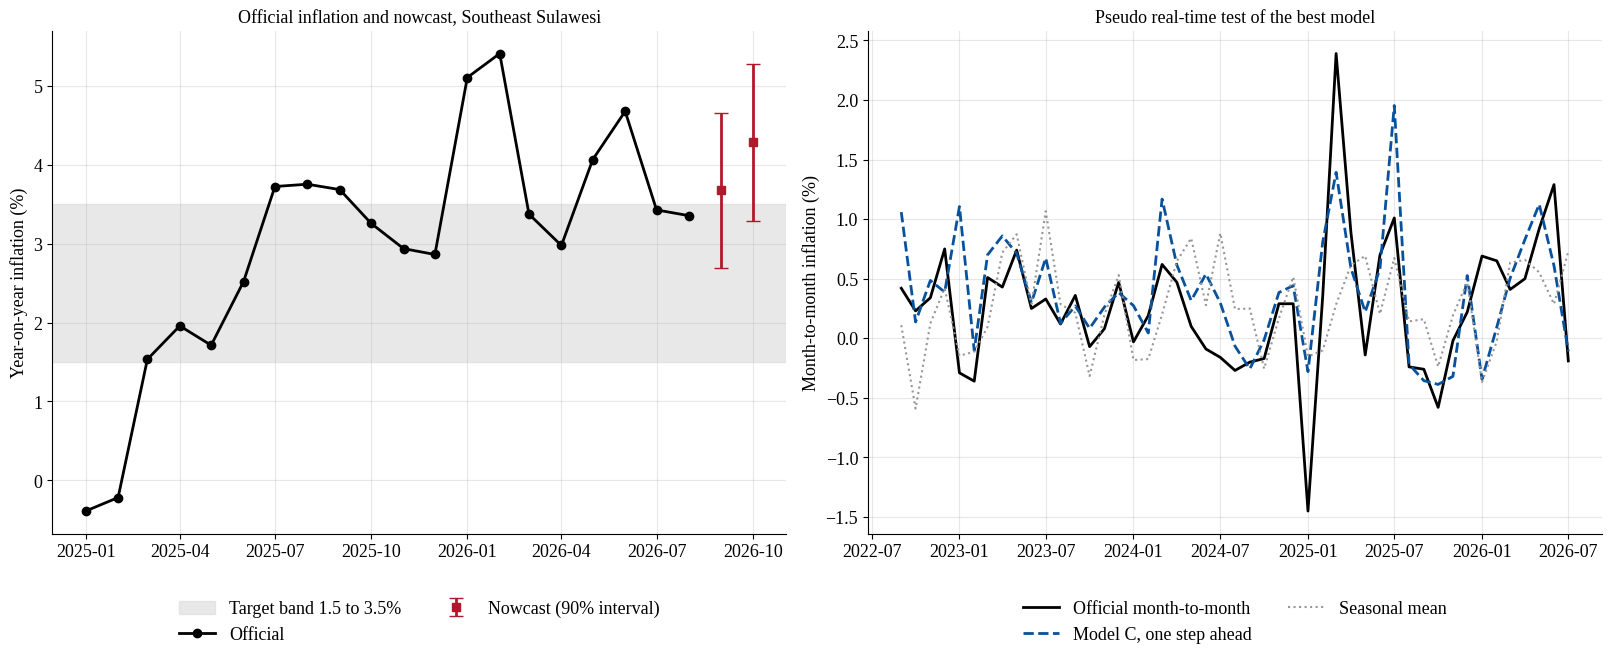

Model dengan galat terkecil pada uji waktu nyata adalah model C, dengan galat mutlak rata-rata 0,336 poin persen
inflasi bulanan, dibanding 0,445 poin untuk rata-rata musiman dan 0,484 poin untuk inflasi bulan sebelumnya (47
bulan uji). Karena harga PIHPS dan indeks harga dibayar petani untuk bulan-bulan ke depan belum tersedia, nowcast
memakai model A. Inflasi tahunan 2026-09 diperkirakan 3,68 persen (rentang 90 persen 2,69 sampai 4,66 persen), dan
2026-10 4,28 persen. Setiap rilis resmi baru menjadi titik awal nowcast bulan berikutnya dan memperbarui koefisien
model.



In [6]:
c18 = D['c18']
m1 = c18[(c18['region_code'] == 7400) & (c18['coicop_code'] == '0')].set_index('period')['inflation_mtm_pct']
m2 = cpi[(cpi['region_code'] == 7400) & (cpi['coicop_code'] == '0')].set_index('period')['inflation_mtm_pct']
MTM = pd.concat([m1[m1.index < '2024-01'], m2]).sort_index().astype(float)
MTM.loc[RESMI['period']] = RESMI['mtm']
PETA_PIHPS = {'Beras': 'BERAS', 'Bawang Merah': 'BAWANG MERAH', 'Bawang Putih': 'BAWANG PUTIH', 'Cabai Merah': 'CABAI MERAH', 'Cabai Rawit': 'CABAI RAWIT',
              'Daging Ayam': 'DAGING AYAM RAS', 'Daging Sapi': 'DAGING SAPI', 'Gula Pasir': 'GULA PASIR', 'Minyak Goreng': 'MINYAK GORENG', 'Telur Ayam': 'TELUR AYAM RAS'}
W_PIHPS = {g: float(it7.loc[it7['name'].str.upper().str.strip() == n, 'w'].sum()) for g, n in PETA_PIHPS.items()}
ph = D['pihps'][D['pihps']['is_aggregate'].astype(bool)]
harga = ph.pivot_table(index='period', columns=['commodity_group', 'region_code'], values='price_filled')
dlog = np.log(harga).diff()
X_PANGAN = pd.Series({p: sum(W_PIHPS[g] * 100 * np.nanmean([dlog.loc[p, (g, c)] for c in (7471, 7472) if (g, c) in dlog.columns]) for g in W_PIHPS)
                      for p in dlog.index[1:]})
ibt = D['ibit'][D['ibit']['subsector'] == 'all_farmers'].set_index('period')['ib'].sort_index()
X_IB = (100 * np.log(ibt).diff()).dropna()
X_SAT, NAMA_SAT = None, None
if SAT is not None:
    kol_sat = [c for c in ['sst_c', 'chl_mg_m3', 'rain_mm'] if c in SAT.columns]
    if kol_sat:
        NAMA_SAT = kol_sat[0]
        s_ = SAT.groupby('period')[NAMA_SAT].mean().sort_index()
        X_SAT = s_ - s_.groupby(s_.index.str[5:7]).transform('mean')

def musiman(p, sampai):
    v = MTM[(MTM.index < sampai) & (MTM.index.str[5:7] == p[5:7])]
    return float(v.mean()) if len(v) else float(MTM[MTM.index < sampai].mean())

MODEL = {'A': ('Model A: previous month, seasonal pattern, PIHPS prices at the start of the month', lambda p: [1, MTM.get(geser(p, -1), np.nan), musiman(p, p), X_PANGAN.get(p, np.nan)]),
         'B': ('Model B: model A plus PIHPS prices at the start of the next month', lambda p: [1, MTM.get(geser(p, -1), np.nan), musiman(p, p), X_PANGAN.get(p, np.nan), X_PANGAN.get(geser(p, 1), np.nan)]),
         'C': ('Model C: model B plus the index of prices paid by farmers', lambda p: [1, MTM.get(geser(p, -1), np.nan), musiman(p, p), X_PANGAN.get(p, np.nan), X_PANGAN.get(geser(p, 1), np.nan), X_IB.get(p, np.nan)])}
if X_SAT is not None:
    MODEL['S'] = ('Model S: model A plus satellite indicator ' + NAMA_SAT, lambda p: [1, MTM.get(geser(p, -1), np.nan), musiman(p, p), X_PANGAN.get(p, np.nan), X_SAT.get(p, np.nan)])

def jalankan_rls(fx, lam=0.98):
    rows = [(p, fx(p), MTM[p]) for p in MTM.index if np.all(np.isfinite(fx(p)))]
    if len(rows) < 24:
        return None
    n0 = max(18, int(len(rows) * 0.4))
    awal = ols([r[1] for r in rows[:n0]], [r[2] for r in rows[:n0]])
    theta, Pm = awal['b'].copy(), awal['inv'].copy()
    uji = []
    for p, x, y in rows[n0:]:
        x = np.asarray(x, float)
        pred = float(x @ theta)
        uji.append({'period': p, 'actual': y, 'model': pred, 'seasonal': x[2], 'previous': x[1]})
        Px = Pm @ x
        k = Px / (lam + x @ Px)
        theta = theta + k * (y - pred)
        Pm = (Pm - np.outer(k, Px)) / lam
    uji = pd.DataFrame(uji)
    penuh = ols([r[1] for r in rows], [r[2] for r in rows])
    return {'theta': theta, 'uji': uji, 'n': len(rows), 'n0': n0, 'full': penuh,
            'mae': (uji['actual'] - uji['model']).abs().mean(), 'mae_seas': (uji['actual'] - uji['seasonal']).abs().mean(),
            'mae_prev': (uji['actual'] - uji['previous']).abs().mean(), 'rmse': float(np.sqrt(((uji['actual'] - uji['model']) ** 2).mean()))}

HASIL_NC = {k: jalankan_rls(f) for k, (nama, f) in MODEL.items()}
S03 = pd.DataFrame([{'Model': MODEL[k][0], 'Observations': h['n'], 'Test months': len(h['uji']), 'MAE model (pp)': h['mae'], 'MAE seasonal mean (pp)': h['mae_seas'],
                     'MAE previous month (pp)': h['mae_prev'], 'RMSE model (pp)': h['rmse']} for k, h in HASIL_NC.items() if h])
simpan_tabel(S03.round(4), 'S03_nowcast_backtest', 'Pseudo real-time evaluation of the nowcasting models')
display(S03.round(3))

TERAKHIR = MTM.index.max()
TARGET_NC = []
lvl = P['gen'].loc[TERAKHIR]
prev = MTM[TERAKHIR]
for h in (1, 2):
    p = geser(TERAKHIR, h)
    x = MODEL['A'][1](p)
    if not np.isfinite(x[1]):
        x[1] = prev
    if not np.isfinite(x[3]):
        hist = X_PANGAN[X_PANGAN.index.str[5:7] == p[5:7]]
        x[3] = float(hist.mean()) if len(hist) else 0.0
    hA = HASIL_NC['A']
    v = float(np.asarray(x) @ hA['theta'])
    lo, hi = v - 1.645 * hA['rmse'], v + 1.645 * hA['rmse']
    base = P['gen'].loc[geser(p, -12)]
    TARGET_NC.append({'Month': p, 'Nowcast mtm (%)': v, 'Lower 90% (mtm)': lo, 'Upper 90% (mtm)': hi,
                      'Nowcast yoy (%)': 100 * (lvl * (1 + v / 100) / base - 1), 'Lower 90% (yoy)': 100 * (lvl * (1 + lo / 100) / base - 1),
                      'Upper 90% (yoy)': 100 * (lvl * (1 + hi / 100) / base - 1), 'Model': 'A'})
    lvl, prev = lvl * (1 + v / 100), v
S04 = pd.DataFrame(TARGET_NC)
simpan_tabel(S04.round(4), 'S04_nowcast', 'Inflation nowcast for the coming months')
display(S04.round(3))

yoy_hist = pd.Series({p: 100 * (P['gen'].loc[p] / P['gen'].loc[geser(p, -12)] - 1) for p in PERIODE_X if geser(p, -12) in P['gen'].index and np.isfinite(P['gen'].loc[geser(p, -12)])})
fig, axs = plt.subplots(1, 2, figsize=(16, 6.5), constrained_layout=True)
ax = axs[0]
ya = yoy_hist[yoy_hist.index >= '2025-01']
tg = pd.PeriodIndex(ya.index, freq='M').to_timestamp()
ax.axhspan(1.5, 3.5, color='#d9d9d9', alpha=0.6, label='Target band 1.5 to 3.5%')
ax.plot(tg, ya.values, color='black', marker='o', lw=2, label='Official')
tn = pd.PeriodIndex(S04['Month'], freq='M').to_timestamp()
ax.errorbar(tn, S04['Nowcast yoy (%)'], yerr=[S04['Nowcast yoy (%)'] - S04['Lower 90% (yoy)'], S04['Upper 90% (yoy)'] - S04['Nowcast yoy (%)']],
            fmt='s', color='#b2182b', capsize=5, lw=2, label='Nowcast (90% interval)')
ax.set_ylabel('Year-on-year inflation (%)')
ax.set_title('Official inflation and nowcast, Southeast Sulawesi')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2, frameon=False)
ax = axs[1]
best_key = min((k for k in HASIL_NC if HASIL_NC[k]), key=lambda k: HASIL_NC[k]['mae'])
u = HASIL_NC[best_key]['uji']
tu = pd.PeriodIndex(u['period'], freq='M').to_timestamp()
ax.plot(tu, u['actual'], color='black', lw=2, label='Official month-to-month')
ax.plot(tu, u['model'], color='#08519c', lw=2, ls='--', label=f'Model {best_key}, one step ahead')
ax.plot(tu, u['seasonal'], color='#969696', lw=1.5, ls=':', label='Seasonal mean')
ax.set_ylabel('Month-to-month inflation (%)')
ax.set_title('Pseudo real-time test of the best model')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2, frameon=False)
simpan_gambar(fig, 'S01_nowcast', 'Inflation nowcast and pseudo real-time test')
hb = HASIL_NC[best_key]
tafsir('S04', f"Model dengan galat terkecil pada uji waktu nyata adalah model {best_key}, dengan galat mutlak rata-rata {angka(hb['mae'], 3)} poin persen inflasi bulanan, "
       f"dibanding {angka(hb['mae_seas'], 3)} poin untuk rata-rata musiman dan {angka(hb['mae_prev'], 3)} poin untuk inflasi bulan sebelumnya ({len(hb['uji'])} bulan uji). "
       f"Karena harga PIHPS dan indeks harga dibayar petani untuk bulan-bulan ke depan belum tersedia, nowcast memakai model A. Inflasi tahunan {S04.iloc[0]['Month']} diperkirakan "
       f"{angka(S04.iloc[0]['Nowcast yoy (%)'])} persen (rentang 90 persen {angka(S04.iloc[0]['Lower 90% (yoy)'])} sampai {angka(S04.iloc[0]['Upper 90% (yoy)'])} persen), "
       f"dan {S04.iloc[1]['Month']} {angka(S04.iloc[1]['Nowcast yoy (%)'])} persen. Setiap rilis resmi baru menjadi titik awal nowcast bulan berikutnya dan memperbarui koefisien model.")

## Langkah 6. Sasaran inflasi menjadi arahan harga per komoditas

Proyeksi dasar tiap subkelompok memakai rata-rata perubahan logaritma pada bulan kalender yang sama, lalu indeks umum disusun kembali dengan bobot tersirat. Karena IHK adalah penjumlahan tertimbang indeks komoditas, perubahan harga komoditas $i$ sebesar $\delta_{i}$ terhadap lintasan dasar menggeser indeks umum secara linear:

$$\Delta I_{T} = K \sum_{i} w_{i}\, I^{b}_{s(i),T}\, \delta_{i}, \qquad \min_{\delta} \sum_{i} \kappa_{i}\delta_{i}^{2} \ \text{dengan syarat}\ \Delta I_{T} = I_{T-12}(1 + \pi^{*}/100) - I^{b}_{T}$$

Solusinya berbentuk $\delta_{i} = \lambda K w_{i} I^{b}_{s(i),T} / \kappa_{i}$ yang dipotong pada batas tiap komponen, dengan $\lambda$ dicari secara bagi dua. Komponen diatur pemerintah diberi bobot kesulitan $\kappa$ dua kali komponen bergejolak, dan komponen inti empat kali. Batas penyesuaian kumulatif: bergejolak 20 persen, diatur pemerintah 10 persen, inti 5 persen. Arahan dilaporkan dalam dua sasaran: cukup kembali ke dalam rentang dan tepat di titik tengah.

,Code,Commodity,Component,CPI weight,Baseline monthly change (%),"Guided monthly change, back inside band (%)","Cumulative adjustment, back inside band",Contribution to the adjustment (pp),At bound,"Guided monthly change, midpoint (%)","Cumulative adjustment, midpoint","Guided monthly change, volatile food only (%)"
0,01.1.101001,BERAS,Volatile food,5.091,-0.512,-1.176,-2.644,-0.143,False,-3.149,-10.189,-1.692
1,06.2.701152,BENSIN,Administered prices,4.330,-0.036,-0.331,-1.173,-0.056,False,-1.186,-4.520,NaN
2,03.4.302033,TARIF LISTRIK,Administered prices,4.194,0.012,-0.238,-0.996,-0.041,False,-0.962,-3.840,NaN
3,01.4.203011,ROKOK KRETEK FILTER,Administered prices,2.506,0.338,0.145,-0.767,-0.024,False,-0.412,-2.957,NaN
4,01.1.103046,IKAN LAYANG/ IKAN BENGGOL,Volatile food,1.865,-0.512,-0.754,-0.969,-0.019,False,-1.454,-3.733,-0.939
5,03.4.302025,BAHAN BAKAR RUMAH TANGGA,Administered prices,2.352,0.012,-0.128,-0.559,-0.013,False,-0.531,-2.154,NaN
6,06.3.701005,ANGKUTAN UDARA,Administered prices,1.841,-0.002,-0.135,-0.532,-0.012,False,-0.519,-2.052,NaN
7,01.1.103037,IKAN KEMBUNG/IKAN GEMBUNG/ IKAN BANYAR/IKAN GE...,Volatile food,1.147,-0.512,-0.660,-0.595,-0.007,False,-1.088,-2.295,-0.774
8,01.1.103066,IKAN SELAR/ IKAN TUDE,Volatile food,0.946,-0.512,-0.634,-0.491,-0.005,False,-0.986,-1.892,-0.728
9,01.1.103017,IKAN CAKALANG/ IKAN SISIK,Volatile food,0.812,-0.512,-0.617,-0.422,-0.004,False,-0.919,-1.626,-0.697


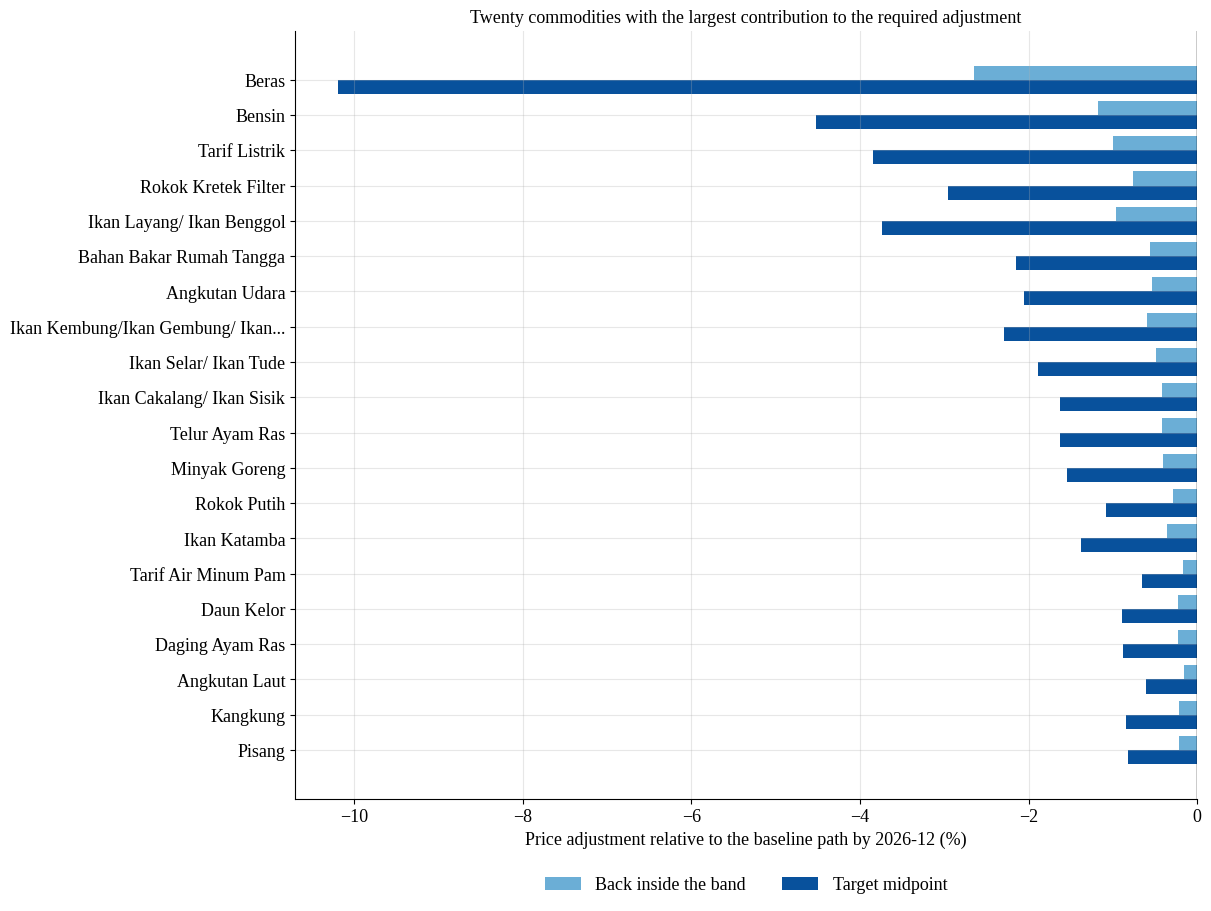

Tanpa intervensi baru, inflasi tahunan Sulawesi Tenggara 2026-12 diproyeksikan 3,85 persen. Untuk kembali ke dalam
rentang sasaran (3,50 persen), indeks umum perlu lebih rendah 0,337 persen dari lintasan dasar; untuk tepat di
titik tengah perlu 1,300 persen. Lima komoditas dengan sumbangan terbesar pada sasaran kembali ke rentang adalah
Beras (arahan perubahan harga -1,18 persen per bulan, lintasan dasar -0,51 persen); Bensin (arahan perubahan harga
-0,33 persen per bulan, lintasan dasar -0,04 persen); Tarif Listrik (arahan perubahan harga -0,24 persen per bulan,
lintasan dasar 0,01 persen); Rokok Kretek Filter (arahan perubahan harga 0,14 persen per bulan, lintasan dasar 0,34
persen); Ikan Layang/ Ikan Benggol (arahan perubahan harga -0,75 persen per bulan, lintasan dasar -0,51 persen).
Semua sasaran dapat dicapai dalam batas penyesuaian yang ditetapkan. Karena harga bensin, tarif listrik, dan cukai
rokok ditetapkan pemerintah pusat, kita juga menghitung varian yang hanya memakai komp

In [7]:
TARGET_BULAN = '2026-12'
SASARAN, DEVIASI = 2.5, 1.0
H12 = [geser(BARU, h) for h in range(1, 13)]

def proyeksi_dasar(r):
    R = REG[r]
    sub = R['sub'].loc[PERIODE_X]
    dl = np.log(sub).diff()
    dl['m'] = [int(p[5:]) for p in dl.index]
    mus = dl.groupby('m').mean().reindex(range(1, 13)).fillna(0.0)
    lvl = sub.loc[BARU].copy()
    proj = {}
    for p in H12:
        lvl = lvl * np.exp(mus.loc[int(p[5:]), sub.columns])
        proj[p] = lvl.copy()
    proj = pd.DataFrame(proj).T
    K = R['gen'].loc[BARU] / (sub.loc[BARU] * R['ws']).sum()
    genb = (proj * R['ws']).sum(axis=1) * K
    yoyb = pd.Series({p: 100 * (genb[p] / R['gen'].loc[geser(p, -12)] - 1) for p in H12})
    return {'proj': proj, 'K': K, 'genb': genb, 'yoyb': yoyb}

BASE = {r: proyeksi_dasar(r) for r in WIL}
BATAS = {'VF': (-0.20, 0.20), 'AP': (-0.10, 0.10), 'CORE': (-0.05, 0.05)}
KAPPA = {'VF': 1.0, 'AP': 2.0, 'CORE': 4.0}

def inversi(r, T, target, kelas=('VF', 'AP')):
    B, it = BASE[r], ITEM[r]
    Ireq = REG[r]['gen'].loc[geser(T, -12)] * (1 + target / 100)
    dreq = Ireq - B['genb'][T]
    c = it[it['cls'].isin(kelas) & ~it['residual']].copy()
    c['v'] = B['K'] * c['w'] * c['sub'].map(B['proj'].loc[T])
    c['k'] = c['cls'].map(KAPPA)
    c['lo'] = c['cls'].map(lambda k: BATAS[k][0])
    c['hi'] = c['cls'].map(lambda k: BATAS[k][1])
    total = lambda lam: float((c['v'] * np.clip(lam * c['v'] / c['k'], c['lo'], c['hi'])).sum())
    lo, hi = -1.0, 1.0
    while total(lo) > dreq and lo > -1e12:
        lo *= 2
    while total(hi) < dreq and hi < 1e12:
        hi *= 2
    for _ in range(200):
        mid = 0.5 * (lo + hi)
        if total(mid) < dreq:
            lo = mid
        else:
            hi = mid
    lam = 0.5 * (lo + hi)
    c['delta'] = np.clip(lam * c['v'] / c['k'], c['lo'], c['hi'])
    Hn = H12.index(T) + 1
    I0 = c['sub'].map(REG[r]['sub'].loc[BARU])
    c['base_monthly'] = (np.power(c['sub'].map(B['proj'].loc[T]) / I0, 1 / Hn) - 1) * 100
    c['guided_monthly'] = (np.power(np.power(1 + c['base_monthly'] / 100, Hn) * (1 + c['delta']), 1 / Hn) - 1) * 100
    c['effect_pp'] = 100 * c['v'] * c['delta'] / REG[r]['gen'].loc[geser(T, -12)]
    c['at_bound'] = (np.isclose(c['delta'], c['lo']) | np.isclose(c['delta'], c['hi']))
    capai = total(lam)
    return {'rows': c.sort_values('effect_pp', key=np.abs, ascending=False), 'dreq': dreq, 'feasible': abs(capai - dreq) < 1e-6 * max(1, abs(dreq)),
            'yoy': 100 * ((B['genb'][T] + capai) / REG[r]['gen'].loc[geser(T, -12)] - 1), 'deltas': dict(zip(c['code'], 100 * c['delta']))}

yb = BASE[7400]['yoyb'][TARGET_BULAN]
tepi = SASARAN + DEVIASI if yb > SASARAN + DEVIASI else (SASARAN - DEVIASI if yb < SASARAN - DEVIASI else yb)
INV_TEPI = inversi(7400, TARGET_BULAN, tepi)
INV_MID = inversi(7400, TARGET_BULAN, SASARAN)
INV_VF = inversi(7400, TARGET_BULAN, tepi, kelas=('VF',))
arahan = INV_TEPI['rows'][['code', 'name', 'cls', 'w', 'base_monthly', 'guided_monthly', 'delta', 'effect_pp', 'at_bound']].merge(
    INV_MID['rows'][['code', 'guided_monthly', 'delta']].rename(columns={'guided_monthly': 'guided_mid', 'delta': 'delta_mid'}), on='code', how='left').merge(
    INV_VF['rows'][['code', 'guided_monthly']].rename(columns={'guided_monthly': 'guided_vf'}), on='code', how='left')
S05 = arahan.rename(columns={'code': 'Code', 'name': 'Commodity', 'cls': 'Component', 'w': 'CPI weight', 'base_monthly': 'Baseline monthly change (%)',
                             'guided_monthly': 'Guided monthly change, back inside band (%)', 'delta': 'Cumulative adjustment, back inside band',
                             'effect_pp': 'Contribution to the adjustment (pp)', 'at_bound': 'At bound', 'guided_mid': 'Guided monthly change, midpoint (%)',
                             'delta_mid': 'Cumulative adjustment, midpoint', 'guided_vf': 'Guided monthly change, volatile food only (%)'})
S05['CPI weight'] = S05['CPI weight'] * 100
S05['Cumulative adjustment, back inside band'] = S05['Cumulative adjustment, back inside band'] * 100
S05['Cumulative adjustment, midpoint'] = S05['Cumulative adjustment, midpoint'] * 100
S05['Component'] = S05['Component'].map({'VF': 'Volatile food', 'AP': 'Administered prices', 'CORE': 'Core'})
simpan_tabel(S05.round(4), 'S05_price_guidance_by_commodity', f'Commodity price guidance to meet the inflation target in {TARGET_BULAN}')
display(S05.head(20).round(3))

fig, ax = plt.subplots(figsize=(12, 9), constrained_layout=True)
t20 = S05.head(20).iloc[::-1]
yy = np.arange(len(t20))
ax.barh(yy + 0.2, t20['Cumulative adjustment, back inside band'], height=0.4, color='#6baed6', label='Back inside the band')
ax.barh(yy - 0.2, t20['Cumulative adjustment, midpoint'], height=0.4, color='#08519c', label='Target midpoint')
ax.set_yticks(yy)
ax.set_yticklabels([textwrap.shorten(str(n).title(), 34, placeholder='...') for n in t20['Commodity']])
ax.axvline(0, color='black', lw=1)
ax.set_xlabel(f'Price adjustment relative to the baseline path by {TARGET_BULAN} (%)')
ax.set_title('Twenty commodities with the largest contribution to the required adjustment')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=2, frameon=False)
simpan_gambar(fig, 'S02_price_guidance', 'Commodity price guidance')
t5 = S05.head(5)
tafsir('S05', f"Tanpa intervensi baru, inflasi tahunan Sulawesi Tenggara {TARGET_BULAN} diproyeksikan {angka(yb)} persen. Untuk kembali ke dalam rentang sasaran ({angka(tepi)} persen), "
       f"indeks umum perlu {('lebih rendah' if INV_TEPI['dreq'] < 0 else 'lebih tinggi')} {angka(abs(INV_TEPI['dreq']) / BASE[7400]['genb'][TARGET_BULAN] * 100, 3)} persen dari lintasan dasar; "
       f"untuk tepat di titik tengah perlu {angka(abs(INV_MID['dreq']) / BASE[7400]['genb'][TARGET_BULAN] * 100, 3)} persen. Lima komoditas dengan sumbangan terbesar pada sasaran kembali ke rentang adalah "
       + '; '.join(f"{str(r_['Commodity']).title()} (arahan perubahan harga {angka(r_['Guided monthly change, back inside band (%)'], 2)} persen per bulan, lintasan dasar {angka(r_['Baseline monthly change (%)'], 2)} persen)" for _, r_ in t5.iterrows())
       + f". Semua sasaran {'dapat' if INV_TEPI['feasible'] and INV_MID['feasible'] else 'tidak seluruhnya dapat'} dicapai dalam batas penyesuaian yang ditetapkan. "
       f"Karena harga bensin, tarif listrik, dan cukai rokok ditetapkan pemerintah pusat, kita juga menghitung varian yang hanya memakai komponen bergejolak, yaitu komoditas yang dapat dipengaruhi "
       f"TPID melalui pasokan dan distribusi. Varian ini {'dapat' if INV_VF['feasible'] else 'tidak dapat'} mencapai sasaran kembali ke rentang; arahan untuk beras menjadi "
       f"{angka(INV_VF['rows'].loc[INV_VF['rows']['name'].str.upper().str.startswith('BERAS'), 'guided_monthly'].iloc[0], 2)} persen per bulan (kolom terakhir tabel S05).")

## Langkah 7. Skenario harga rinci dan dampaknya sampai kabupaten/kota

Distribusi pengeluaran tiap kabupaten/kota dikalibrasi seperti pada notebook kedua: sebaran log-normal dipilih agar P0 dan P1 resmi 2025 tepat, lalu persentase penduduk miskin disesuaikan ke jumlah penduduk miskin provinsi Maret 2026. Setiap kabupaten/kota mengikuti kota IHK acuan terdekat. Perubahan harga komoditas menggeser garis kemiskinan melalui harga subkelompok Makanan (dengan pangsa makanan dalam garis kemiskinan) dan harga nonmakanan:

$$\frac{GK_{k}}{GK^{b}_{k}} = s_{f}\frac{\sum_{i \in makanan} w_{ij}(1 + \delta_{i})}{\sum_{i \in makanan} w_{ij}} + (1 - s_{f})\frac{\sum_{i \notin makanan} w_{ij}(1 + \delta_{i})}{\sum_{i \notin makanan} w_{ij}}, \qquad P0_{k} = \Phi\!\left(d_{k} + \frac{\ln(GK_{k}/GK^{b}_{k}) - \ln(Y_{k}/Y^{b}_{k})}{\sigma_{k}}\right)$$

Pendapatan rumah tangga $Y_{k}$ hanya berubah melalui penerimaan nelayan, sebanding dengan ketergantungan wilayah pada perikanan tangkap. Skenario yang diuji mencakup kenaikan harga beras, bensin, emas perhiasan, tarif angkutan udara, penurunan harga ikan segar (dengan dan tanpa penerusan ke nelayan), serta arahan harga dari langkah 6.

,Scenario,Inflation yoy (%),Change vs baseline (pp),Real purchasing power (%),Fishers terms of trade (baseline = 100),Change in poor population (persons)
0,Rice price +5%,4.120,0.270,-0.260,99.848,10539.070
1,Gasoline price +10%,4.329,0.479,-0.461,99.732,2267.849
2,Gold jewellery price +10%,3.988,0.137,-0.132,99.923,360.269
3,Air fares +15%,4.177,0.326,-0.314,99.817,1553.943
4,"Fresh fish price -5%, margin only",3.454,-0.396,0.382,100.224,-15176.704
5,"Fresh fish price -5%, passed to fishers",3.454,-0.396,0.382,99.154,-8650.138
6,Price guidance back inside band,3.500,-0.350,0.337,100.198,-8376.549
7,Price guidance to midpoint,2.500,-1.350,1.300,100.768,-31517.142


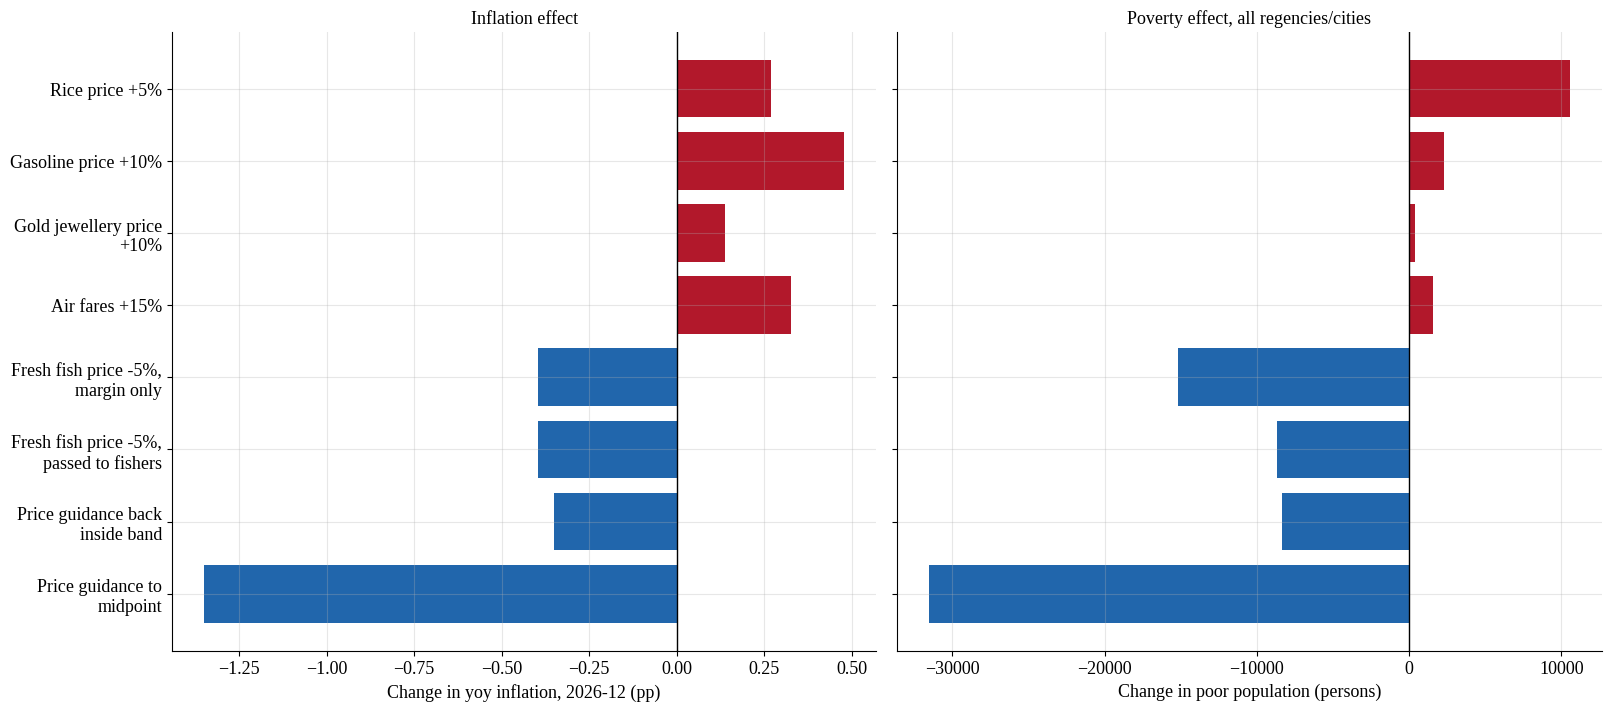

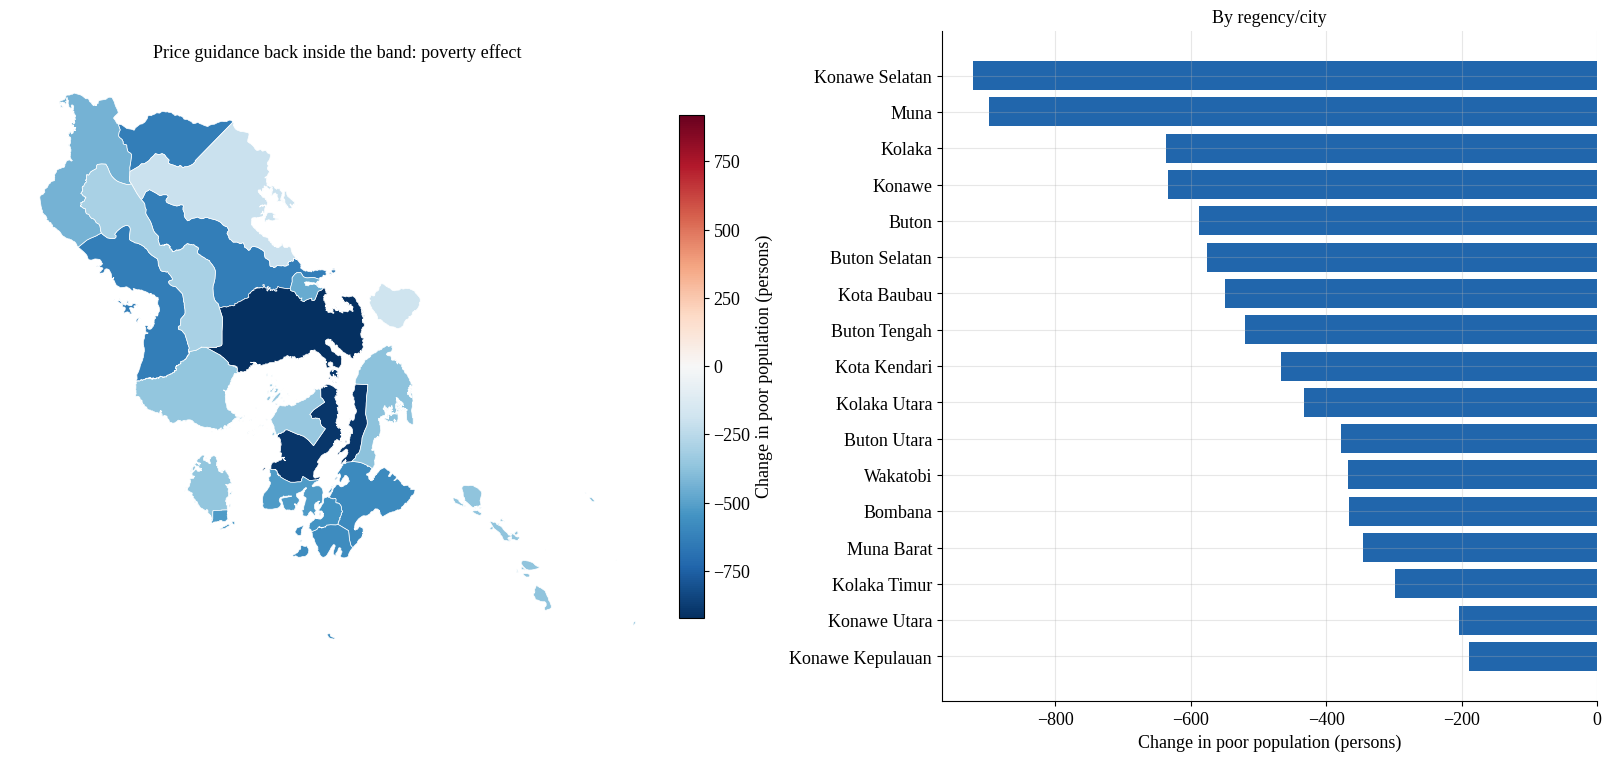

Pada 2026-12, kenaikan harga beras 5 persen menambah inflasi tahunan 0,270 poin dan jumlah penduduk miskin 10.539
orang; kenaikan harga bensin 10 persen menambah inflasi 0,479 poin dan penduduk miskin 2.268 orang. Kenaikan harga
emas perhiasan 10 persen menambah inflasi 0,137 poin tetapi hampir tidak mengubah garis kemiskinan (360 orang),
karena bobotnya berada di luar subkelompok Makanan. Penurunan harga ikan segar 5 persen yang berasal dari margin
mengurangi penduduk miskin 15.177 orang; bila penurunan itu diteruskan ke harga nelayan, pengurangannya tinggal
8.650 orang dan nilai tukar nelayan menjadi 99,15. Arahan harga untuk kembali ke dalam rentang sasaran mengubah
jumlah penduduk miskin berkurang 8.377 orang, dengan penurunan terbesar di Konawe Selatan (922 orang).



In [8]:
pk, spat, pairs, pov = D['pk'], D['spat'], D['pairs'], D['pov']
KAB = sorted(spat['region_code'].unique().tolist())
THN = int(pk.loc[pk['variable'] == 'poverty_rate_p0', 'year'].max())
prof = pk[(pk['year'] == THN) & pk['region_code'].isin(KAB)].pivot_table(index=['region_code', 'region_name'], columns='variable', values='value').reset_index()
pop = D['pop']
prof['population_2026'] = prof['region_code'].map(pop[(pop['year'] == 2026) & (pop['category'] == 'total') & (pop['series'] == 'projection_sp2020')].set_index('region_code')['value'])
prof['gk_rp'] = prof['region_code'].map(pk[pk['variable'] == 'poverty_line'].sort_values('year').groupby('region_code')['value'].last())
prof = prof.merge(spat[['region_code', 'cluster']], on='region_code', how='left')
prof['code'] = prof['region_code'].astype(str).str[2:]

def p1_ln(sg, d):
    return norm.cdf(d) - np.exp(-sg * d + sg ** 2 / 2) * norm.cdf(d - sg)
d_obs = norm.ppf(prof['poverty_rate_p0'] / 100)
prof['sigma'] = [brentq(lambda sg: p1_ln(sg, d) - t / 100, 1e-3, 5.0) for d, t in zip(d_obs, prof['poverty_gap_index_p1'])]
mp = pov[(pov['variable'] == 'poor_population') & (pov['area'] == 'total') & (pov['component'] == 'total')].sort_values('period')
PER_MISKIN, MISKIN_PROV = mp['period'].iloc[-1], float(mp['value'].iloc[-1]) * 1000
SKALA = MISKIN_PROV / (prof['poverty_rate_p0'] / 100 * prof['population_2026']).sum()
prof['p0_base'] = prof['poverty_rate_p0'] * SKALA
prof['d_base'] = norm.ppf(prof['p0_base'] / 100)
prof['poor_base'] = prof['p0_base'] / 100 * prof['population_2026']
prof['eta'] = norm.pdf(prof['d_base']) / (prof['sigma'] * norm.cdf(prof['d_base']))
REF = {}
for k in KAB:
    if k in KOTA:
        REF[k] = k
        continue
    c = pairs[(pairs['region_code_from'] == k) & pairs['region_code_to'].isin(KOTA)]
    sama = c[c['same_landmass'] == 1]
    REF[k] = int((sama if len(sama) else c).sort_values('distance_km').iloc[0]['region_code_to'])
prof['ref'] = prof['region_code'].map(REF)
g24 = D['grdp'][(D['grdp']['variable'] == 'grdp_current_price') & (D['grdp']['year'] == 2024)].set_index('region_code')['value']
prof['fsh'] = (prof['region_code'].map(D['kkpk'].set_index('region_code')['value_million_rp']) / (prof['region_code'].map(g24) * 1000)).fillna(0.0)
gkt = pov[(pov['variable'] == 'poverty_line') & (pov['area'] == 'total')].pivot_table(index='period', columns='component', values='value').dropna().sort_index()
S_F = float(gkt['food'].iloc[-1] / gkt['total'].iloc[-1])

def rasio_gk(j, deltas):
    it = ITEM[j]
    d = it['code'].map(deltas).fillna(0.0).to_numpy() / 100
    f = (it['sub'] == '011').to_numpy()
    w = it['w'].to_numpy()
    return S_F * (w[f] * (1 + d[f])).sum() / w[f].sum() + (1 - S_F) * (w[~f] * (1 + d[~f])).sum() / w[~f].sum()

def dampak_kab(gk, rev=1.0, beta=1.0, tau=0.0, rhoT=0.6, sig=None):
    g = prof['ref'].map(gk).to_numpy(dtype=float)
    inc = 1 + beta * prof['fsh'].to_numpy() * (rev - 1)
    s = prof['sigma'].to_numpy() if sig is None else sig
    p0 = norm.cdf(prof['d_base'].to_numpy() + (np.log(g) - np.log(np.maximum(inc, 1e-6)) + np.log(1 - rhoT * tau)) / s) * 100
    dp = p0 - prof['p0_base'].to_numpy()
    return dp, dp / 100 * prof['population_2026'].to_numpy()

def skenario(r, T, deltas):
    B, it = BASE[r], ITEM[r]
    d = it['code'].map(deltas).fillna(0.0) / 100
    Ib = it['sub'].map(B['proj'].loc[T])
    I12 = it['sub'].map(REG[r]['sub'].loc[geser(T, -12)])
    IT12 = REG[r]['gen'].loc[geser(T, -12)]
    dI = float((B['K'] * it['w'] * Ib * d).sum())
    kontrib = 100 * B['K'] * it['w'] * (Ib * (1 + d) - I12) / IT12
    return {'yoy': 100 * ((B['genb'][T] + dI) / IT12 - 1), 'yoyb': B['yoyb'][T], 'cpi_ratio': (B['genb'][T] + dI) / B['genb'][T],
            'by_cls': kontrib.groupby(it['cls']).sum(), 'by_grp': kontrib.groupby(it['grp']).sum()}

def skenario_lengkap(nama, deltas, rho_ikan=0.0):
    sc = skenario(7400, TARGET_BULAN, deltas)
    it = ITEM[7400]
    wf = it.loc[it['fish'], 'w']
    d_ikan = float((wf * it.loc[it['fish'], 'code'].map(deltas).fillna(0.0)).sum() / wf.sum()) / 100 if wf.sum() > 0 else 0.0
    p_ratio = 1 + rho_ikan * d_ikan / (1 - PARAM['m0'])
    gk = {j: rasio_gk(j, deltas) for j in KOTA}
    dp, dm = dampak_kab(gk, p_ratio)
    return {'Scenario': nama, 'Inflation yoy (%)': sc['yoy'], 'Change vs baseline (pp)': sc['yoy'] - sc['yoyb'],
            'Real purchasing power (%)': -100 * (sc['cpi_ratio'] - 1),
            'Fishers terms of trade (baseline = 100)': 100 * p_ratio ** PARAM['theta'] / sc['cpi_ratio'] ** PARAM['psi'],
            'Change in poor population (persons)': float(dm.sum()), '_dm': dm, '_gk': gk}

nama_item7 = it7.set_index('code')['name'].str.upper()
pilih = lambda cond, v: {c: v for c, n in nama_item7.items() if cond(c, n)}
SKEN = [('Rice price +5%', pilih(lambda c, n: n.startswith('BERAS'), 5.0), 0.0),
        ('Gasoline price +10%', pilih(lambda c, n: n.startswith('BENSIN'), 10.0), 0.0),
        ('Gold jewellery price +10%', pilih(lambda c, n: 'EMAS PERHIASAN' in n, 10.0), 0.0),
        ('Air fares +15%', pilih(lambda c, n: 'ANGKUTAN UDARA' in n, 15.0), 0.0),
        ('Fresh fish price -5%, margin only', {c: -5.0 for c in it7.loc[it7['fish'], 'code']}, 0.0),
        ('Fresh fish price -5%, passed to fishers', {c: -5.0 for c in it7.loc[it7['fish'], 'code']}, 1.0),
        ('Price guidance back inside band', INV_TEPI['deltas'], 0.0),
        ('Price guidance to midpoint', INV_MID['deltas'], 0.0)]
HSK = [skenario_lengkap(n, d, rho) for n, d, rho in SKEN]
S06 = pd.DataFrame([{k: v for k, v in h.items() if not k.startswith('_')} for h in HSK])
simpan_tabel(S06.round(4), 'S06_price_scenarios', f'Detailed price scenarios: inflation and poverty effects in {TARGET_BULAN}')
display(S06.round(3))
S07 = pd.DataFrame({'Code': prof['code'], 'Regency/city': prof['region_name'], 'Reference CPI region': prof['ref'].map(NAMA_WIL),
                    f'Baseline poor population {PER_MISKIN[:4]}': prof['poor_base']})
for h in HSK:
    S07[h['Scenario']] = h['_dm']
simpan_tabel(S07.round(1), 'S07_price_scenarios_by_region', 'Change in poor population by scenario and regency/city (persons)')

fig, axs = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)
lab = [textwrap.fill(s, 24) for s in S06['Scenario']]
yy = np.arange(len(S06))[::-1]
axs[0].barh(yy, S06['Change vs baseline (pp)'], color=['#b2182b' if v > 0 else '#2166ac' for v in S06['Change vs baseline (pp)']])
axs[0].set_yticks(yy); axs[0].set_yticklabels(lab)
axs[0].axvline(0, color='black', lw=1)
axs[0].set_xlabel(f'Change in yoy inflation, {TARGET_BULAN} (pp)')
axs[0].set_title('Inflation effect')
axs[1].barh(yy, S06['Change in poor population (persons)'], color=['#b2182b' if v > 0 else '#2166ac' for v in S06['Change in poor population (persons)']])
axs[1].set_yticks(yy); axs[1].set_yticklabels([])
axs[1].axvline(0, color='black', lw=1)
axs[1].set_xlabel('Change in poor population (persons)')
axs[1].set_title('Poverty effect, all regencies/cities')
simpan_gambar(fig, 'S03_price_scenarios', 'Inflation and poverty effects of detailed price scenarios')

def gambar_peta(ax, nilai, label_cb, divergen=True):
    patches, vals = [], []
    for ft in GEO['features']:
        kode = int(ft['properties']['region_code'])
        geom = ft['geometry']
        for poly in (geom['coordinates'] if geom['type'] == 'MultiPolygon' else [geom['coordinates']]):
            patches.append(MplPolygon(np.array(poly[0]), closed=True))
            vals.append(nilai.get(kode, np.nan))
    v = np.array(vals, float)
    b = max(np.nanmax(np.abs(v)), 1e-9)
    pc = PatchCollection(patches, cmap=plt.get_cmap('RdBu_r' if divergen else 'Blues'), edgecolor='white', linewidth=0.5,
                         norm=TwoSlopeNorm(vmin=-b, vcenter=0, vmax=b) if divergen else None)
    pc.set_array(np.ma.masked_invalid(v))
    ax.add_collection(pc); ax.autoscale_view(); ax.set_aspect('equal'); ax.set_axis_off()
    cb = plt.colorbar(pc, ax=ax, shrink=0.75, pad=0.02)
    cb.set_label(label_cb)

h_tepi = next(h for h in HSK if h['Scenario'] == 'Price guidance back inside band')
fig, axs = plt.subplots(1, 2, figsize=(16, 7.5), constrained_layout=True)
gambar_peta(axs[0], dict(zip(prof['region_code'], h_tepi['_dm'])), 'Change in poor population (persons)')
axs[0].set_title('Price guidance back inside the band: poverty effect')
urut = np.argsort(h_tepi['_dm'])
axs[1].barh(np.arange(len(prof)), h_tepi['_dm'][urut][::-1], color='#2166ac')
axs[1].set_yticks(np.arange(len(prof)))
axs[1].set_yticklabels(prof['region_name'].to_numpy()[urut][::-1])
axs[1].set_xlabel('Change in poor population (persons)')
axs[1].set_title('By regency/city')
simpan_gambar(fig, 'S04_guidance_poverty_map', 'Poverty effects of the price guidance by regency/city')
kal = [f"Pada {TARGET_BULAN}, kenaikan harga beras 5 persen menambah inflasi tahunan {angka(S06.iloc[0]['Change vs baseline (pp)'], 3)} poin dan jumlah penduduk miskin "
       f"{angka(S06.iloc[0]['Change in poor population (persons)'], 0)} orang; kenaikan harga bensin 10 persen menambah inflasi {angka(S06.iloc[1]['Change vs baseline (pp)'], 3)} poin "
       f"dan penduduk miskin {angka(S06.iloc[1]['Change in poor population (persons)'], 0)} orang."]
kal.append(f"Kenaikan harga emas perhiasan 10 persen menambah inflasi {angka(S06.iloc[2]['Change vs baseline (pp)'], 3)} poin tetapi hampir tidak mengubah garis kemiskinan "
           f"({angka(S06.iloc[2]['Change in poor population (persons)'], 0)} orang), karena bobotnya berada di luar subkelompok Makanan.")
kal.append(f"Penurunan harga ikan segar 5 persen yang berasal dari margin mengurangi penduduk miskin {angka(-S06.iloc[4]['Change in poor population (persons)'], 0)} orang; bila penurunan itu "
           f"diteruskan ke harga nelayan, pengurangannya tinggal {angka(-S06.iloc[5]['Change in poor population (persons)'], 0)} orang dan nilai tukar nelayan menjadi {angka(S06.iloc[5]['Fishers terms of trade (baseline = 100)'], 2)}.")
kal.append(f"Arahan harga untuk kembali ke dalam rentang sasaran mengubah jumlah penduduk miskin {arah(h_tepi['Change in poor population (persons)'])}, dengan penurunan terbesar di "
           f"{prof['region_name'].iloc[int(np.argmin(h_tepi['_dm']))]} ({angka(-h_tepi['_dm'].min(), 0)} orang).")
tafsir('S06', ' '.join(kal))

## Langkah 8. Perencana pengurangan kemiskinan SA-DDSO

Tuas kebijakan yang dicari ada lima: penurunan margin distribusi ikan ($f$), operasi pasar ikan ($s$), tambahan penyerapan permintaan ikan ($a$), moderasi harga pangan lain per bulan ($g$), dan transfer terarah sebesar $\tau$ kali garis kemiskinan per orang miskin. Transfer diasumsikan tepat sasaran sebesar $\rho_{T}$ (nilai dasar 0,6, diuji 0,4 sampai 0,8) sehingga ambang kemiskinan efektif bergeser sebesar $\ln(1 - \rho_{T}\tau)$. Biaya transfer dihitung $\tau \times GK_{k} \times 12 \times$ jumlah penduduk miskin dasar.

Empat tujuan diminimumkan: perubahan jumlah penduduk miskin wilayah sasaran, jarak inflasi tahunan dari titik tengah sasaran, biaya transfer, dan negatif nilai tukar nelayan. Syaratnya, penurunan penduduk miskin paling sedikit sebesar target. Alur SA-DDSO yang dijalankan:

1. Sampel Latin Hypercube dievaluasi dengan simulator penuh (sistem dinamis pasar ikan dan distribusi pengeluaran 17 kabupaten/kota).
2. Surrogate RBF (thin plate spline) dilatih dan divalidasi pada sampel baru. Bila R² di bawah 0,98 atau NRMSE di atas 0,03 untuk salah satu keluaran, sampel ditambah dan surrogate dilatih ulang.
3. NSGA-III (Deb dan Jain, 2014) mencari front Pareto pada surrogate dengan titik acuan Das dan Dennis.
4. Seluruh solusi diverifikasi ulang dengan simulator penuh. Bila galat surrogate melebihi 5 persen dari rentang keluaran, titik-titik itu ditambahkan ke data latih dan pencarian diulang.
5. Solusi terpilih diuji dengan 300 kali pengacakan parameter untuk memperoleh rentang 90 persen.

Empat tuas harga dan pasar tidak diberi biaya fiskal eksplisit di dalam model, sehingga batas atasnya berperan sebagai batas kelayakan pelaksanaan. Bila solusi menyentuh batas atas suatu tuas, artinya tuas itu dipakai penuh dalam rentang yang dianggap layak; batas ini dapat diubah pada variabel `LEVERS` sesuai hasil diskusi dengan TPID.

Uji simulator: solusi kompromi notebook pertama dari Agustus 2026 -> inflasi 3.232 | nilai tukar nelayan 101.59 | perubahan penduduk miskin -31241
Perencana provinsi selesai dalam 0.8 detik; 56 dari 56 solusi memenuhi target; front Pareto 56 solusi.


,Step,Training points,R2 (poverty/inflation/NTN),NRMSE,Valid
0,Surrogate validation round 1,160,1.0000 / 1.0000 / 1.0000,0.0013 / 0.0014 / 0.0004,True
1,Verification of NSGA-III solutions with the fu...,220,,"max 0.0141, mean 0.0028",True


,Distribution margin reduction,Fish market operation (share of supply),Additional fish demand absorption,Other food price moderation per month,Targeted transfer (share of poverty line),Change in poor population (persons),Inflation yoy (%),Fishers terms of trade,Transfer cost (IDR billion per year)
0,0.3000,0.0700,0.0000,0.0040,0.0258,-59005.7384,2.8338,100.8418,40.3539
1,0.3000,0.0703,0.0000,0.0039,0.0258,-58996.4900,2.8336,100.8389,40.3539
2,0.3000,0.0703,0.0000,0.0040,0.0219,-56348.5824,2.8293,100.8414,34.2970
3,0.2914,0.1000,0.0299,0.0040,0.0487,-74521.1871,2.8498,100.8233,76.1045
4,0.2914,0.1000,0.0211,0.0040,0.0418,-70591.5268,2.8052,100.7311,65.3181
5,0.2623,0.0652,0.0374,0.0033,0.0441,-63892.3480,3.1439,101.0705,68.9714
6,0.2623,0.0652,0.0374,0.0033,0.0382,-59639.3053,3.1439,101.0705,59.7128
7,0.3000,0.0711,0.0001,0.0040,0.0591,-82361.1526,2.8253,100.8339,92.3357
8,0.3000,0.0686,0.0025,0.0040,0.0104,-47514.2878,2.8495,100.8837,16.3002
9,0.2991,0.0710,0.0000,0.0039,0.0605,-83027.8734,2.8331,100.8261,94.4753


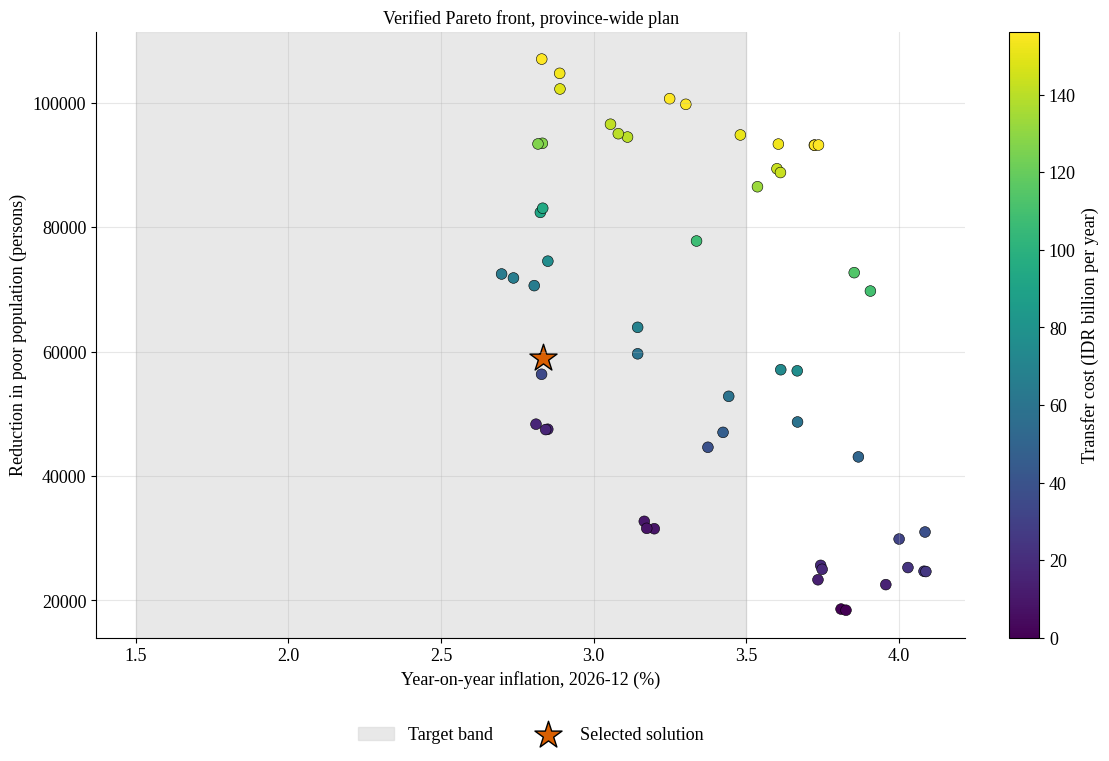

Surrogate memenuhi ambang validitas setelah 1 putaran validasi dan diverifikasi ulang dengan simulator penuh (max
0.0141, mean 0.0028 dari rentang keluaran). Dari 56 solusi akhir, 56 memenuhi target penurunan paling sedikit
10.000 orang. Solusi terpilih: penurunan margin distribusi ikan 30,0 persen, operasi pasar 7,0 persen pasokan,
tambahan penyerapan permintaan 0,0 persen, moderasi harga pangan lain 0,40 persen per bulan, dan transfer terarah
2,6 persen garis kemiskinan (biaya Rp 40,4 miliar per tahun). Pada 300 kali pengacakan parameter, penurunan
penduduk miskin bermedian 58.973 orang (rentang 90 persen 48.848 sampai 69.260 orang), inflasi 2,86 persen (2,55
sampai 3,07 persen), peluang target tercapai 100,0 persen, dan peluang inflasi di dalam rentang sasaran 100,0
persen.



In [9]:
LEVERS = [('f', 'Distribution margin reduction', 0.0, 0.30), ('s', 'Fish market operation (share of supply)', 0.0, 0.10),
          ('a', 'Additional fish demand absorption', 0.0, 0.15), ('g', 'Other food price moderation per month', 0.0, 0.004),
          ('tau', 'Targeted transfer (share of poverty line)', 0.0, 0.10)]
LO, HI = np.array([l[2] for l in LEVERS]), np.array([l[3] for l in LEVERS])

def sd(z, prm, H):
    p, K, path = 1.0, 1.0, []
    for h in range(H):
        ramp = min(1.0, (h + 1) / prm['ramp'])
        f, s_, a = z[0] * ramp, z[1] * ramp, z[2] * ramp
        r = np.exp(-z[3] * (h + 1))
        c = (1 - prm['m0']) * p + prm['m0'] * (1 - f)
        cpi_r = 1 + prm['w_fish'] * (c - 1) + prm['w_rest'] * (r - 1)
        ntn = p ** prm['theta'] / cpi_r ** prm['psi']
        dmd, q = c ** prm['eps_d'] * (1 + a), K + s_
        path.append((c, p, K, r, ntn))
        K = K + (ntn ** prm['eps_s'] - K) / prm['tau']
        p = p * np.exp(prm['phi'] * (dmd - q))
    return path

MASKER = {'all': np.ones(len(prof), bool)}
MASKER.update({k: (prof['region_code'].to_numpy() == k) for k in KAB})

def simulator(z, T=TARGET_BULAN, pilih='all', rhoT=0.6, prm=None, beta=1.0, fish_mult=1.0, sig=None):
    prm = PARAM if prm is None else prm
    c, p, K, r, ntn = sd(z, prm, H12.index(T) + 1)[-1]
    fw = FISHW[7400]
    wf = fw['fish'] * fish_mult
    cpi_r = 1 + wf * (c - 1) + (fw['w011'] - wf) * (r - 1)
    yoy = 100 * (BASE[7400]['genb'][T] * cpi_r / REG[7400]['gen'].loc[geser(T, -12)] - 1)
    gk = {}
    for j in KOTA:
        wfj = FISHW[j]['fish'] * fish_mult
        wrj = FISHW[j]['w011'] - wfj
        gk[j] = S_F * (wfj * c + wrj * r) / (wfj + wrj) + (1 - S_F)
    dp, dm = dampak_kab(gk, p * K, beta, z[4], rhoT, sig)
    m = MASKER[pilih]
    biaya = float((z[4] * prof['gk_rp'].to_numpy() * 12 * prof['poor_base'].to_numpy())[m].sum()) / 1e9
    return {'dsel': float(dm[m].sum()), 'yoy': yoy, 'ntn': 100 * ntn, 'cost': biaya, 'dm': dm}

cek = simulator(np.array([SETELAN['compromise_levers'][k] for k in 'fsag'] + [0.0]))
print('Uji simulator: solusi kompromi notebook pertama dari Agustus 2026 -> inflasi', round(cek['yoy'], 3), '| nilai tukar nelayan', round(cek['ntn'], 2),
      '| perubahan penduduk miskin', round(cek['dsel']))

def lhs(n, d, rng):
    u = (rng.permuted(np.tile(np.arange(n), (d, 1)), axis=1).T + rng.random((n, d))) / n
    return u

def das_dennis(M, p):
    out = []
    def rec(sisa, kedalaman, cur):
        if kedalaman == M - 1:
            out.append(cur + [sisa / p])
            return
        for i in range(sisa + 1):
            rec(sisa - i, kedalaman + 1, cur + [i / p])
    rec(p, 0, [])
    return np.array(out)

def matriks_dominasi(F, CV):
    le = np.all(F[:, None, :] <= F[None, :, :], axis=2)
    lt = np.any(F[:, None, :] < F[None, :, :], axis=2)
    A = np.where(CV[:, None] < CV[None, :], True, np.where(CV[:, None] > CV[None, :], False, le & lt))
    np.fill_diagonal(A, False)
    return A

def sortir_front(F, CV):
    A = matriks_dominasi(F, CV)
    cnt = A.sum(axis=0).astype(int)
    sisa = np.ones(len(F), bool)
    fronts = []
    while sisa.any():
        cur = np.where(sisa & (cnt <= 0))[0]
        if len(cur) == 0:
            cur = np.where(sisa)[0]
        fronts.append(cur)
        sisa[cur] = False
        cnt = cnt - A[cur].sum(axis=0)
    return fronts

def nsga3(evalf, lo, hi, n_obj, rng, gens=60, p_ref=5):
    refs = das_dennis(n_obj, p_ref)
    wn = refs / np.linalg.norm(refs, axis=1, keepdims=True)
    N, d = int(np.ceil(len(refs) / 4) * 4), len(lo)
    X = lo + lhs(N, d, rng) * (hi - lo)
    F, CV = evalf(X)
    for _ in range(gens):
        A = matriks_dominasi(F, CV)
        i1, i2 = rng.integers(0, N, N), rng.integers(0, N, N)
        win = np.where(A[i1, i2], i1, np.where(A[i2, i1], i2, np.where(rng.random(N) < 0.5, i1, i2)))
        par, Xo = X[win], X[win].copy()
        for k in range(0, N - 1, 2):
            a, b = par[k], par[k + 1]
            for j in range(d):
                if rng.random() > 0.5 or abs(a[j] - b[j]) < 1e-12:
                    continue
                u = rng.random()
                bq = (2 * u) ** (1 / 16) if u <= 0.5 else (1 / (2 * (1 - u))) ** (1 / 16)
                Xo[k, j] = 0.5 * ((1 + bq) * a[j] + (1 - bq) * b[j])
                Xo[k + 1, j] = 0.5 * ((1 - bq) * a[j] + (1 + bq) * b[j])
        mut = rng.random(Xo.shape) < 1 / d
        u = rng.random(Xo.shape)
        dl = np.where(u < 0.5, (2 * u) ** (1 / 21) - 1, 1 - (2 * (1 - u)) ** (1 / 21))
        Xo = np.clip(np.where(mut, Xo + dl * (hi - lo), Xo), lo, hi)
        Fo, CVo = evalf(Xo)
        RX, RF, RC = np.vstack([X, Xo]), np.vstack([F, Fo]), np.concatenate([CV, CVo])
        fr = sortir_front(RF, RC)
        S, l = [], 0
        while l < len(fr) and len(S) + len(fr[l]) <= N:
            S.extend(fr[l].tolist())
            l += 1
        if len(S) == N or l >= len(fr):
            pilihan = np.array(S[:N])
        else:
            last = fr[l].tolist()
            semua = np.array(S + last)
            Ft = RF[semua] - RF[semua].min(axis=0)
            ext = np.array([Ft[np.argmin(np.max(Ft / np.where(np.arange(n_obj) == k, 1.0, 1e-6), axis=1))] for k in range(n_obj)])
            try:
                inter = 1 / np.linalg.solve(ext, np.ones(n_obj))
                if not np.all(np.isfinite(inter)) or np.any(inter <= 1e-12):
                    raise ValueError
            except Exception:
                inter = Ft.max(axis=0)
            Fn = Ft / np.where(inter > 1e-12, inter, 1e-12)
            proj = Fn @ wn.T
            dist = np.sqrt(np.maximum((Fn ** 2).sum(axis=1, keepdims=True) - proj ** 2, 0))
            assoc, dmin = dist.argmin(axis=1), dist.min(axis=1)
            nS = len(S)
            rho = np.bincount(assoc[:nS], minlength=len(refs)).astype(float)
            cand, dipilih, excl = list(range(nS, len(semua))), [], np.zeros(len(refs), bool)
            while nS + len(dipilih) < N:
                rr = np.where(excl, np.inf, rho)
                J = np.where(rr == rr.min())[0]
                j = int(rng.choice(J))
                cj = [c for c in cand if assoc[c] == j]
                if not cj:
                    excl[j] = True
                    continue
                pk_ = min(cj, key=lambda c: dmin[c]) if rho[j] == 0 else cj[int(rng.integers(len(cj)))]
                dipilih.append(pk_); cand.remove(pk_); rho[j] += 1
            pilihan = np.concatenate([semua[:nS], semua[dipilih]])
        X, F, CV = RX[pilihan], RF[pilihan], RC[pilihan]
    return X, F, CV

def metrik(Pd, Y):
    r2 = 1 - ((Pd - Y) ** 2).sum(axis=0) / ((Y - Y.mean(axis=0)) ** 2).sum(axis=0)
    nrmse = np.sqrt(((Pd - Y) ** 2).mean(axis=0)) / np.maximum(Y.max(axis=0) - Y.min(axis=0), 1e-12)
    return r2, nrmse

def perencana(pilih='all', target=10000, rhoT=0.6, bobot=(1, 1, 1, 1), T=TARGET_BULAN, n_latih=160, gens=60, seed=1):
    rng = np.random.default_rng(seed)
    real = lambda U: LO + U * (HI - LO)
    keluar = lambda U: np.array([[r['dsel'], r['yoy'], r['ntn']] for r in (simulator(z, T, pilih, rhoT) for z in real(U))])
    log = []
    Xu = lhs(n_latih, 5, rng)
    Y = keluar(Xu)
    for putaran in range(4):
        sur = RBFInterpolator(Xu, Y, kernel='thin_plate_spline', smoothing=1e-9)
        V = lhs(60, 5, rng)
        Yv = keluar(V)
        r2, nr = metrik(sur(V), Yv)
        sah = bool(np.all(r2 >= 0.98) and np.all(nr <= 0.03))
        log.append({'Step': f'Surrogate validation round {putaran + 1}', 'Training points': len(Xu), 'R2 (poverty/inflation/NTN)': ' / '.join(f'{v:.4f}' for v in r2),
                    'NRMSE': ' / '.join(f'{v:.4f}' for v in nr), 'Valid': sah})
        Xu, Y = np.vstack([Xu, V]), np.vstack([Y, Yv])
        if sah:
            break
        tambah = lhs(80, 5, rng)
        Xu, Y = np.vstack([Xu, tambah]), np.vstack([Y, keluar(tambah)])
    sur = RBFInterpolator(Xu, Y, kernel='thin_plate_spline', smoothing=1e-9)
    satuan_biaya = float((prof['gk_rp'].to_numpy() * 12 * prof['poor_base'].to_numpy())[MASKER[pilih]].sum()) / 1e9
    rentang = max(1.0, float(Y[:, 0].max() - Y[:, 0].min()))
    def evalf(Z, model):
        Yp = model((Z - LO) / (HI - LO))
        F = np.column_stack([Yp[:, 0], np.abs(Yp[:, 1] - SASARAN), Z[:, 4] * satuan_biaya, -Yp[:, 2]])
        return F, np.maximum(0.0, Yp[:, 0] + target)
    for it_ in range(2):
        Xs, _, _ = nsga3(lambda Z: evalf(Z, sur), LO, HI, 4, rng, gens=gens)
        Yf = np.array([[r['dsel'], r['yoy'], r['ntn']] for r in (simulator(z, T, pilih, rhoT) for z in Xs)])
        galat = np.abs(Yf[:, 0] - sur((Xs - LO) / (HI - LO))[:, 0]) / rentang
        log.append({'Step': f'Verification of NSGA-III solutions with the full simulator, iteration {it_ + 1}', 'Training points': len(Xu),
                    'R2 (poverty/inflation/NTN)': '', 'NRMSE': f'max {galat.max():.4f}, mean {galat.mean():.4f}', 'Valid': bool(galat.max() <= 0.05)})
        if galat.max() <= 0.05:
            break
        Xu, Y = np.vstack([Xu, (Xs - LO) / (HI - LO)]), np.vstack([Y, Yf])
        sur = RBFInterpolator(Xu, Y, kernel='thin_plate_spline', smoothing=1e-9)
    F = np.column_stack([Yf[:, 0], np.abs(Yf[:, 1] - SASARAN), Xs[:, 4] * satuan_biaya, -Yf[:, 2]])
    CV = np.maximum(0.0, Yf[:, 0] + target)
    layak = CV <= 1e-9
    idx = np.where(layak)[0] if layak.any() else np.arange(len(Xs))
    A = matriks_dominasi(F[idx], CV[idx])
    par = idx[~A.any(axis=0)]
    Fp = F[par]
    Fn = (Fp - Fp.min(axis=0)) / np.where(np.ptp(Fp, axis=0) > 0, np.ptp(Fp, axis=0), 1)
    skor = np.sqrt((np.array(bobot) * Fn ** 2).sum(axis=1))
    urut = par[np.argsort(skor)]
    return {'X': Xs[urut], 'Y': Yf[urut], 'cost': Xs[urut, 4] * satuan_biaya, 'feasible': int(layak.sum()), 'n': len(Xs), 'log': pd.DataFrame(log), 'reach': bool(layak.any())}

def ketidakpastian(z, pilih='all', target=0, rhoT=0.6, n=300, seed=7, T=TARGET_BULAN):
    rng = np.random.default_rng(seed)
    hasil = []
    for _ in range(n):
        prm = dict(PARAM, eps_d=rng.uniform(-1.2, -0.4), eps_s=rng.uniform(0.1, 0.6), tau=rng.uniform(3, 12), phi=rng.uniform(0.3, 1.0), m0=rng.uniform(0.25, 0.45))
        r = simulator(z, T, pilih, rng.uniform(max(0.2, rhoT - 0.2), min(1.0, rhoT + 0.2)), prm, rng.uniform(0.5, 1.5), rng.uniform(0.8, 1.2),
                      prof['sigma'].to_numpy() * np.exp(rng.normal(0, 0.1, len(prof))))
        hasil.append((r['dsel'], r['yoy'], r['ntn'], r['dm']))
    ds = np.array([h[0] for h in hasil]); yo = np.array([h[1] for h in hasil]); nt = np.array([h[2] for h in hasil]); dm = np.array([h[3] for h in hasil])
    q = lambda a: np.percentile(a, [5, 50, 95], axis=0)
    return {'dsel': q(ds), 'yoy': q(yo), 'ntn': q(nt), 'dm': q(dm), 'reach': float((ds <= -target).mean()) if target else np.nan,
            'band': float(((yo >= SASARAN - DEVIASI) & (yo <= SASARAN + DEVIASI)).mean())}

TARGET_PROV = 10000
t0 = time.time()
PLAN = perencana('all', TARGET_PROV)
UNC = ketidakpastian(PLAN['X'][0], 'all', TARGET_PROV)
print(f'Perencana provinsi selesai dalam {time.time() - t0:.1f} detik; {PLAN["feasible"]} dari {PLAN["n"]} solusi memenuhi target; front Pareto {len(PLAN["X"])} solusi.')
simpan_tabel(PLAN['log'], 'S08_saddso_log', 'SA-DDSO process log for the province-wide plan')
display(PLAN['log'])
S09 = pd.DataFrame(PLAN['X'], columns=[l[1] for l in LEVERS])
S09['Change in poor population (persons)'] = PLAN['Y'][:, 0]
S09['Inflation yoy (%)'] = PLAN['Y'][:, 1]
S09['Fishers terms of trade'] = PLAN['Y'][:, 2]
S09['Transfer cost (IDR billion per year)'] = PLAN['cost']
simpan_tabel(S09.round(5), 'S09_pareto_province', f'Verified Pareto solutions for reducing poverty by at least {TARGET_PROV:,} persons')
display(S09.head(10).round(4))

fig, ax = plt.subplots(figsize=(11, 7.5), constrained_layout=True)
ax.axvspan(SASARAN - DEVIASI, SASARAN + DEVIASI, color='#d9d9d9', alpha=0.6, label='Target band')
sc_ = ax.scatter(S09['Inflation yoy (%)'], -S09['Change in poor population (persons)'], c=S09['Transfer cost (IDR billion per year)'], cmap='viridis', s=60, edgecolor='black', lw=0.4)
ax.scatter(S09['Inflation yoy (%)'].iloc[:1], -S09['Change in poor population (persons)'].iloc[:1], marker='*', s=420, color='#d95f02', edgecolor='black', label='Selected solution')
cb = plt.colorbar(sc_, ax=ax)
cb.set_label('Transfer cost (IDR billion per year)')
ax.set_xlabel(f'Year-on-year inflation, {TARGET_BULAN} (%)')
ax.set_ylabel('Reduction in poor population (persons)')
ax.set_title('Verified Pareto front, province-wide plan')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=False)
simpan_gambar(fig, 'S05_pareto_province', 'Verified Pareto front of the province-wide plan')
zb = PLAN['X'][0]
tafsir('S08', f"Surrogate memenuhi ambang validitas setelah {int(PLAN['log']['Step'].str.startswith('Surrogate').sum())} putaran validasi dan diverifikasi ulang dengan simulator penuh "
       f"({PLAN['log'].iloc[-1]['NRMSE']} dari rentang keluaran). Dari {PLAN['n']} solusi akhir, {PLAN['feasible']} memenuhi target penurunan paling sedikit {angka(TARGET_PROV, 0)} orang. "
       f"Solusi terpilih: penurunan margin distribusi ikan {angka(100 * zb[0], 1)} persen, operasi pasar {angka(100 * zb[1], 1)} persen pasokan, tambahan penyerapan permintaan "
       f"{angka(100 * zb[2], 1)} persen, moderasi harga pangan lain {angka(100 * zb[3], 2)} persen per bulan, dan transfer terarah {angka(100 * zb[4], 1)} persen garis kemiskinan "
       f"(biaya Rp {angka(PLAN['cost'][0], 1)} miliar per tahun). Pada 300 kali pengacakan parameter, penurunan penduduk miskin bermedian {angka(-UNC['dsel'][1], 0)} orang "
       f"(rentang 90 persen {angka(-UNC['dsel'][2], 0)} sampai {angka(-UNC['dsel'][0], 0)} orang), inflasi {angka(UNC['yoy'][1])} persen ({angka(UNC['yoy'][0])} sampai {angka(UNC['yoy'][2])} persen), "
       f"peluang target tercapai {angka(100 * UNC['reach'], 1)} persen, dan peluang inflasi di dalam rentang sasaran {angka(100 * UNC['band'], 1)} persen.")

## Langkah 9. Rencana per kabupaten/kota

Untuk setiap kabupaten/kota, perencana dijalankan dengan target menurunkan 10 persen jumlah penduduk miskin dasarnya. Empat tuas harga dan pasar berlaku untuk seluruh provinsi, sedangkan transfer terarah dan biayanya dihitung untuk wilayah itu saja. Hasilnya menjawab simulasi apa yang perlu dijalankan agar penurunan kemiskinan di wilayah tertentu tercapai, beserta rentang ketidakpastiannya.

Rencana 17 kabupaten/kota selesai dalam 10.3 detik


,Code,Regency/city,Baseline poor 2026,Target reduction (persons),Margin reduction (%),Market operation (%),Demand absorption (%),Other food moderation (% per month),Targeted transfer (% of poverty line),"Reduction, median (persons)","Reduction, P5","Reduction, P95",Probability target reached (%),"Inflation yoy, median (%)",Transfer cost (IDR billion),Target reachable in search
0,01,Buton,15955.30,1596,29.54,4.40,5.81,0.38,4.09,4099.48,2971.43,5181.81,100.00,3.27,2.92,True
1,02,Muna,27436.97,2744,30.00,9.21,2.89,0.36,5.42,7990.38,6174.86,10066.23,100.00,2.93,8.06,True
2,03,Konawe,34120.46,3412,28.39,6.03,0.28,0.35,4.43,5334.61,4133.82,6842.95,99.33,2.96,8.39,True
3,04,Kolaka,24443.70,2444,29.99,6.06,0.92,0.40,6.06,5989.72,4446.93,7978.78,100.00,2.91,8.76,True
4,05,Konawe Selatan,35862.77,3586,30.00,3.21,3.24,0.40,4.28,7273.94,5443.09,9487.98,100.00,3.17,6.81,True
5,06,Bombana,15840.53,1584,30.00,1.72,4.13,0.40,6.97,3755.80,2882.16,4738.66,100.00,3.33,5.85,True
6,07,Wakatobi,15396.22,1540,29.73,4.30,3.35,0.36,7.42,3707.43,2895.65,4676.26,100.00,3.17,5.09,True
7,08,Kolaka Utara,18821.74,1882,30.00,2.30,0.12,0.40,5.82,4008.25,3069.57,5161.09,100.00,3.05,7.25,True
8,09,Buton Utara,8906.11,891,30.00,8.77,1.64,0.37,2.37,2424.14,1927.81,3008.29,100.00,2.87,1.12,True
9,10,Konawe Utara,8633.78,863,30.00,9.03,5.51,0.35,5.07,1775.52,1417.49,2326.04,100.00,3.05,2.23,True


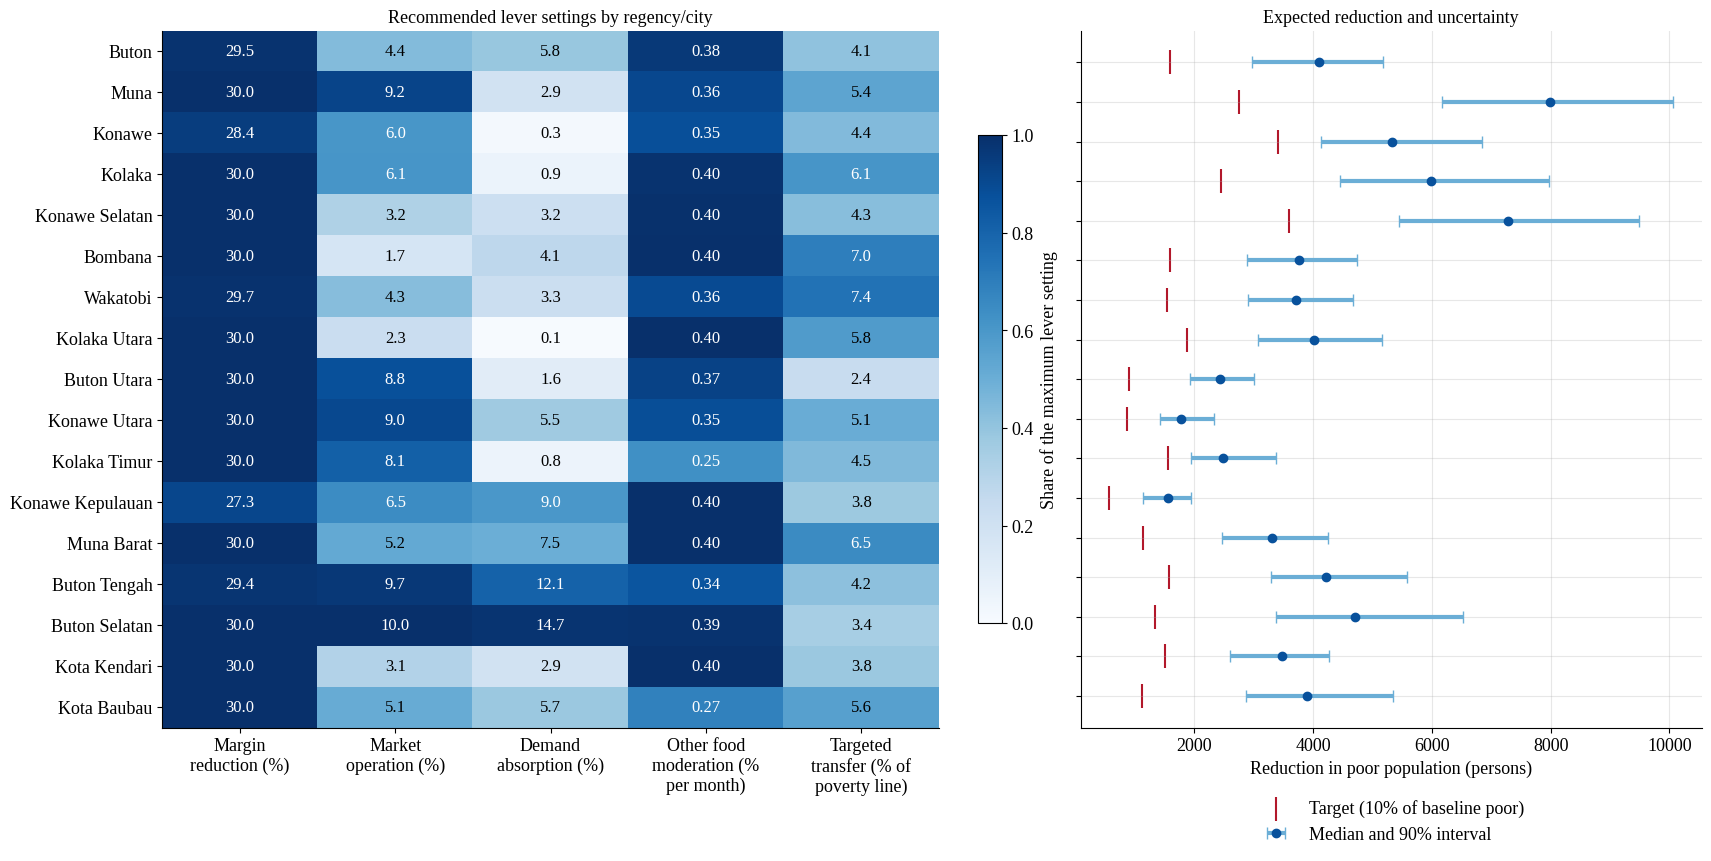

Dengan target 10 persen penduduk miskin dasar, target tercapai dalam pencarian pada 17 dari 17 wilayah, dan peluang
tercapai (dari pengacakan parameter) berkisar 99,3 sampai 100,0 persen. Transfer terarah terbesar dibutuhkan di
Wakatobi (7,4 persen garis kemiskinan) dan terkecil di Buton Utara (2,4 persen). Total biaya transfer bila semua
rencana dijalankan sekaligus Rp 78,3 miliar per tahun; angka ini batas atas karena tuas harga dan pasar yang
berlaku provinsi ikut menurunkan kemiskinan di wilayah lain.



In [10]:
BAG_TARGET = 0.10
baris = []
t0 = time.time()
for i, r in prof.reset_index(drop=True).iterrows():
    tgt = round(BAG_TARGET * r['poor_base'])
    pl = perencana(r['region_code'], tgt, n_latih=120, gens=40, seed=100 + i)
    un = ketidakpastian(pl['X'][0], r['region_code'], tgt, n=150, seed=200 + i)
    z = pl['X'][0]
    baris.append({'Code': r['code'], 'Regency/city': r['region_name'], f'Baseline poor {PER_MISKIN[:4]}': r['poor_base'], 'Target reduction (persons)': tgt,
                  'Margin reduction (%)': 100 * z[0], 'Market operation (%)': 100 * z[1], 'Demand absorption (%)': 100 * z[2], 'Other food moderation (% per month)': 100 * z[3],
                  'Targeted transfer (% of poverty line)': 100 * z[4], 'Reduction, median (persons)': -un['dsel'][1], 'Reduction, P5': -un['dsel'][2], 'Reduction, P95': -un['dsel'][0],
                  'Probability target reached (%)': 100 * un['reach'], 'Inflation yoy, median (%)': un['yoy'][1], 'Transfer cost (IDR billion)': pl['cost'][0],
                  'Target reachable in search': pl['reach']})
S10 = pd.DataFrame(baris)
print(f'Rencana 17 kabupaten/kota selesai dalam {time.time() - t0:.1f} detik')
simpan_tabel(S10.round(3), 'S10_plans_by_region', 'Recommended plans to reduce poverty by 10 percent in each regency/city')
display(S10.round(2))

fig, axs = plt.subplots(1, 2, figsize=(17, 8.5), constrained_layout=True, gridspec_kw={'width_ratios': [1.25, 1]})
kol = ['Margin reduction (%)', 'Market operation (%)', 'Demand absorption (%)', 'Other food moderation (% per month)', 'Targeted transfer (% of poverty line)']
mat = S10[kol].to_numpy() / (np.array([l[3] for l in LEVERS]) * 100)
im = axs[0].imshow(mat, cmap='Blues', vmin=0, vmax=1, aspect='auto')
axs[0].set_yticks(range(len(S10))); axs[0].set_yticklabels(S10['Regency/city'])
axs[0].set_xticks(range(len(kol))); axs[0].set_xticklabels([textwrap.fill(k, 14) for k in kol])
axs[0].grid(False)
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        axs[0].text(j, i, f'{S10[kol[j]].iloc[i]:.2f}' if j == 3 else f'{S10[kol[j]].iloc[i]:.1f}', ha='center', va='center', fontsize=12, color='white' if mat[i, j] > 0.6 else 'black')
cb = fig.colorbar(im, ax=axs[0], shrink=0.7)
cb.set_label('Share of the maximum lever setting')
axs[0].set_title('Recommended lever settings by regency/city')
yy = np.arange(len(S10))
axs[1].errorbar(S10['Reduction, median (persons)'], yy, xerr=[S10['Reduction, median (persons)'] - S10['Reduction, P5'], S10['Reduction, P95'] - S10['Reduction, median (persons)']],
                fmt='o', color='#08519c', ecolor='#6baed6', elinewidth=3, capsize=4, label='Median and 90% interval')
axs[1].scatter(S10['Target reduction (persons)'], yy, marker='|', s=300, color='#b2182b', label='Target (10% of baseline poor)')
axs[1].set_yticks(yy); axs[1].set_yticklabels([])
axs[1].invert_yaxis()
axs[1].set_xlabel('Reduction in poor population (persons)')
axs[1].set_title('Expected reduction and uncertainty')
axs[1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=1, frameon=False)
simpan_gambar(fig, 'S06_plans_by_region', 'Recommended plans and expected poverty reduction by regency/city')
tr = S10.sort_values('Targeted transfer (% of poverty line)', ascending=False)
tafsir('S10', f"Dengan target 10 persen penduduk miskin dasar, target tercapai dalam pencarian pada {int(S10['Target reachable in search'].sum())} dari {len(S10)} wilayah, dan peluang tercapai "
       f"(dari pengacakan parameter) berkisar {angka(S10['Probability target reached (%)'].min(), 1)} sampai {angka(S10['Probability target reached (%)'].max(), 1)} persen. "
       f"Transfer terarah terbesar dibutuhkan di {tr.iloc[0]['Regency/city']} ({angka(tr.iloc[0]['Targeted transfer (% of poverty line)'], 1)} persen garis kemiskinan) dan terkecil di "
       f"{tr.iloc[-1]['Regency/city']} ({angka(tr.iloc[-1]['Targeted transfer (% of poverty line)'], 1)} persen). Total biaya transfer bila semua rencana dijalankan sekaligus "
       f"Rp {angka(S10['Transfer cost (IDR billion)'].sum(), 1)} miliar per tahun; angka ini batas atas karena tuas harga dan pasar yang berlaku provinsi ikut menurunkan kemiskinan di wilayah lain.")

## Langkah 10. Ekspor status model dan paket keluaran

Status model disimpan sebagai berkas JSON agar aplikasi web dapat memulai dari hasil notebook ini: bobot wilayah, koefisien nowcast, proyeksi dasar, arahan harga, kalibrasi kabupaten/kota, parameter sistem dinamis, dan hasil perencana. Ketika data baru masuk, notebook ini cukup dijalankan ulang (atau aplikasi web memperbarui estimasi yang sama secara langsung).

In [11]:
def bersih(o):
    if isinstance(o, dict):
        return {str(k): bersih(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)):
        return [bersih(v) for v in o]
    if isinstance(o, (np.floating, float)):
        return None if not np.isfinite(o) else float(o)
    if isinstance(o, (np.integer,)):
        return int(o)
    if isinstance(o, np.ndarray):
        return bersih(o.tolist())
    if isinstance(o, (np.bool_,)):
        return bool(o)
    return o

STATUS = {'meta': {'created': time.strftime('%Y-%m-%d %H:%M'), 'data_until': BARU, 'target_month': TARGET_BULAN, 'target_mid': SASARAN, 'target_dev': DEVIASI, 'official': RESMI},
          'city_weights': dict(zip(map(str, KOTA), W_KOTA)), 'city_rmse': RMSE_KOTA, 'structural_validation': S01.to_dict('records'),
          'nowcast': {'models': {k: {'name': MODEL[k][0], 'theta': h['theta'], 'b_full': h['full']['b'], 'se_full': h['full']['se'], 'mae': h['mae'], 'mae_seasonal': h['mae_seas'],
                                     'mae_previous': h['mae_prev'], 'rmse': h['rmse'], 'n': h['n']} for k, h in HASIL_NC.items() if h},
                      'targets': S04.to_dict('records'), 'pihps_weights': W_PIHPS, 'satellite_variable': NAMA_SAT},
          'baseline_yoy': {str(r): BASE[r]['yoyb'].to_dict() for r in WIL}, 'price_guidance': S05.head(80).to_dict('records'),
          'kab': prof[['region_code', 'region_name', 'cluster', 'population_2026', 'poverty_rate_p0', 'poverty_gap_index_p1', 'poverty_severity_index_p2', 'gini_ratio',
                       'sigma', 'p0_base', 'd_base', 'poor_base', 'eta', 'ref', 'fsh', 'gk_rp']].to_dict('records'),
          'sd_parameters': PARAM, 'food_share_poverty_line': S_F, 'scale_to_2026': SKALA,
          'plan_province': {'target': TARGET_PROV, 'levers': dict(zip([l[0] for l in LEVERS], PLAN['X'][0])), 'cost_idr_billion': PLAN['cost'][0],
                            'reduction_p5_p50_p95': (-UNC['dsel'][::-1]).tolist(), 'yoy_p5_p50_p95': UNC['yoy'].tolist(), 'prob_reach': UNC['reach'], 'prob_band': UNC['band'],
                            'pareto': S09.head(20).to_dict('records'), 'log': PLAN['log'].to_dict('records')},
          'plans_by_region': S10.to_dict('records'), 'scenarios': S06.to_dict('records')}
with open(os.path.join(SUB['state'], 'model_state.json'), 'w', encoding='utf-8') as f:
    json.dump(bersih(STATUS), f, ensure_ascii=False, indent=1)
with pd.ExcelWriter(os.path.join(OUT_DIR, 'tables_simulasi.xlsx')) as xw:
    pd.DataFrame([{'Sheet': k, 'Title': v[0]} for k, v in TABEL.items()]).to_excel(xw, sheet_name='INDEX', index=False)
    for k, (judul, df_) in TABEL.items():
        df_.to_excel(xw, sheet_name=k[:31], index=False)
with open(os.path.join(SUB['interpretations'], 'interpretasi_otomatis_simulasi.md'), 'w', encoding='utf-8') as f:
    f.write('# Interpretasi otomatis: nowcasting, arahan harga, dan perencana kemiskinan\n\n')
    for k, daftar in TAFSIR.items():
        f.write(f'## {k}\n\n' + '\n\n'.join(daftar) + '\n\n')
pd.DataFrame([{'Type': 'Table', 'Code': k, 'Title': v[0]} for k, v in TABEL.items()] +
             [{'Type': 'Figure', 'Code': k, 'Title': v[0]} for k, v in GAMBAR.items()]).to_csv(os.path.join(OUT_DIR, 'manifest.csv'), index=False)
zip_path = shutil.make_archive(os.path.join(BASE_DIR, 'output_forkestra2026_simulasi'), 'zip', OUT_DIR)
print('Tabel:', len(TABEL), '| Gambar:', len(GAMBAR), '| Berkas ZIP:', zip_path)
if DI_COLAB:
    from google.colab import files
    files.download(zip_path)
else:
    from IPython.display import FileLink, display
    display(FileLink(os.path.relpath(zip_path)))

Tabel: 10 | Gambar: 6 | Berkas ZIP: /content/output_forkestra2026_simulasi.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Daftar pustaka

Badan Pusat Statistik Provinsi Sulawesi Tenggara. (2026, 1 September). *Perkembangan indeks harga konsumen Provinsi Sulawesi Tenggara Agustus 2026* [Rilis resmi, dikutip]. Radio Republik Indonesia Kendari. https://rri.co.id/kendari/asta-cita/2701118/inflasi-sultra-335-persen-tertinggi-kendari-366-persen

Berita Kota Kendari. (2026, 2 September). *Agustus, Sultra catat inflasi 3,35 persen*. https://beritakotakendari.fajar.co.id/2026/09/02/agustus-sultra-catat-inflasi-335-persen/

Das, I., & Dennis, J. E. (1998). Normal-boundary intersection: A new method for generating the Pareto surface in nonlinear multicriteria optimization problems. *SIAM Journal on Optimization, 8*(3), 631-657. https://doi.org/10.1137/S1052623496307510

Deb, K., & Jain, H. (2014). An evolutionary many-objective optimization algorithm using reference-point-based nondominated sorting approach, Part I: Solving problems with box constraints. *IEEE Transactions on Evolutionary Computation, 18*(4), 577-601. https://doi.org/10.1109/TEVC.2013.2281535

Haykin, S. (2014). *Adaptive filter theory* (5th ed.). Pearson.

International Monetary Fund, International Labour Organization, Eurostat, United Nations Economic Commission for Europe, Organisation for Economic Co-operation and Development, & World Bank. (2020). *Consumer price index manual: Concepts and methods*. International Monetary Fund. https://www.elibrary.imf.org/display/book/9781484354841/9781484354841.xml

Kementerian Keuangan Republik Indonesia. (2024). *Peraturan Menteri Keuangan Nomor 31 Tahun 2024 tentang Sasaran Inflasi Tahun 2025, Tahun 2026, dan Tahun 2027*. https://jdih.kemenkeu.go.id/dok/pmk-31-tahun-2024/summary

Lawson, C. L., & Hanson, R. J. (1995). *Solving least squares problems*. Society for Industrial and Applied Mathematics. https://doi.org/10.1137/1.9781611971217

López, J. H., & Servén, L. (2006). *A normal relationship? Poverty, growth, and inequality* (Policy Research Working Paper No. 3814). World Bank. https://doi.org/10.1596/1813-9450-3814

McKay, M. D., Beckman, R. J., & Conover, W. J. (1979). A comparison of three methods for selecting values of input variables in the analysis of output from a computer code. *Technometrics, 21*(2), 239-245. https://doi.org/10.2307/1268522

Sterman, J. D. (2000). *Business dynamics: Systems thinking and modeling for a complex world*. Irwin/McGraw-Hill.

Virtanen, P., Gommers, R., Oliphant, T. E., Haberland, M., Reddy, T., Cournapeau, D., Burovski, E., Peterson, P., Weckesser, W., Bright, J., van der Walt, S. J., Brett, M., Wilson, J., Millman, K. J., Mayorov, N., Nelson, A. R. J., Jones, E., Kern, R., Larson, E., ... SciPy 1.0 Contributors. (2020). SciPy 1.0: Fundamental algorithms for scientific computing in Python. *Nature Methods, 17*(3), 261-272. https://doi.org/10.1038/s41592-019-0686-2